# imports

In [ ]:
import torchimport torchvisionfrom torch import nnimport torchvision.transforms as transformsfrom tqdm.auto import tqdmimport warningsfrom timeit import default_timer as timerimport pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.metrics import confusion_matrixwarnings.filterwarnings('ignore')

## using CUDA

In [192]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Timer

In [193]:
def print_train_time(start: float, end : float, device: torch.device = None):    total_time = end - start    print(f"Train time on {device}: {total_time/60:.3f} minutes\n\n")    return total_time

## Transforming to Tensors

In [194]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

In [195]:
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

## 'Train', 'Validation', 'Test'

In [196]:
train_size = int(0.8 * len(trainset))val_size = len(trainset) - train_sizetrain_subset, val_subset = torch.utils.data.random_split(trainset, [train_size, val_size])# Create DataLoaders for each settrainloader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True)valloader = torch.utils.data.DataLoader(val_subset, batch_size=64, shuffle=False)testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

## Deep Neural Network

In [197]:
class DeepNN(nn.Module):    def __init__(self, input_features=784, output_features=10, hidden_features=104, init_method=None):        super().__init__()        self.layer_stack = nn.Sequential(            nn.Linear(in_features=input_features, out_features=hidden_features),            nn.ReLU(),            nn.Linear(in_features=hidden_features, out_features=hidden_features),            nn.ReLU(),            nn.Linear(in_features=hidden_features, out_features=hidden_features),            nn.ReLU(),            nn.Linear(in_features=hidden_features, out_features=hidden_features),            nn.ReLU(),            nn.Linear(in_features=hidden_features, out_features=output_features),        )        self._initialize_weights(init_method)    def _initialize_weights(self, init_method):        if init_method != None:            for layer in self.layer_stack:                if isinstance(layer, nn.Linear):                    if init_method == 'he':                        nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')                    elif init_method == 'xavier':                        nn.init.xavier_normal_(layer.weight)                    elif init_method == 'random':                        nn.init.normal_(layer.weight, mean=0, std=1)                    nn.init.zeros_(layer.bias)  # Initialize biases to zero    def forward(self, x):        return self.layer_stack(x)

## Wide Nerual Network

In [198]:
class WideNN(nn.Module):    def __init__(self, input_features=784, output_features=10, hidden_features=136, init_method=None):        super().__init__()        self.layer_stack = nn.Sequential(            nn.Linear(in_features=input_features, out_features=hidden_features),            nn.ReLU(),            nn.Linear(in_features=hidden_features, out_features=output_features),        )        self._initialize_weights(init_method)    def _initialize_weights(self, init_method):        if init_method != None:            for layer in self.layer_stack:                if isinstance(layer, nn.Linear):                    if init_method == 'he':                        nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')                    elif init_method == 'xavier':                        nn.init.xavier_normal_(layer.weight)                    elif init_method == 'random':                        nn.init.normal_(layer.weight, mean=0, std=1)                    nn.init.zeros_(layer.bias)  # Initialize biases to zero    def forward(self, x):        return self.layer_stack(x)

In [199]:
deep_model = DeepNN().to(device)wide_model = WideNN().to(device)

In [ ]:
print(f"Deep_model state_dict {deep_model.state_dict}")print(f"Wide_model state_dict {wide_model.state_dict}")

Deep_model state_dict <bound method Module.state_dict of DeepNN(
  (layer_stack): Sequential(
    (0): Linear(in_features=784, out_features=104, bias=True)
    (1): ReLU()
    (2): Linear(in_features=104, out_features=104, bias=True)
    (3): ReLU()
    (4): Linear(in_features=104, out_features=104, bias=True)
    (5): ReLU()
    (6): Linear(in_features=104, out_features=104, bias=True)
    (7): ReLU()
    (8): Linear(in_features=104, out_features=10, bias=True)
  )
)>
Deep_model state_dict <bound method Module.state_dict of WideNN(
  (layer_stack): Sequential(
    (0): Linear(in_features=784, out_features=136, bias=True)
    (1): ReLU()
    (2): Linear(in_features=136, out_features=10, bias=True)
  )
)>


## 'Loss' and 'Optimizer'

In [201]:
deep_loss = nn.CrossEntropyLoss()wide_loss = nn.CrossEntropyLoss()deep_optimizer = torch.optim.Adam(deep_model.parameters(), lr=0.001)wide_optimizer = torch.optim.Adam(wide_model.parameters(), lr=0.001)

## "Train" and "Evaluation" Loop

In [ ]:
def train_and_evaluate(model, trainloader, valloader, loss_fn, optimizer, device, epochs=8):    start_time = timer()    train_losses = []    eval_losses = []    for epoch in range(epochs):        model.train()        train_loss = 0        for images, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs} - Training"):            images, labels = images.to(device), labels.to(device)            images = images.flatten(start_dim=1)            outputs = model(images)            loss = loss_fn(outputs, labels)            optimizer.zero_grad()            loss.backward()            optimizer.step()            train_loss += loss.item()        avg_train_loss = train_loss/len(trainloader)        train_losses.append(avg_train_loss)        print(f" ** Training Loss: {avg_train_loss:.4f}")        model.eval()        correct = 0        total = 0        eval_loss = 0        with torch.inference_mode():            for images, labels in tqdm(valloader, desc=f"Epoch {epoch+1}/{epochs} - Evaluation"):                images, labels = images.to(device), labels.to(device)                images = images.flatten(start_dim=1)                outputs = model(images)                predicted = torch.argmax(outputs, dim=1)                total += labels.size(0)                correct += (predicted == labels).sum().item()                loss = loss_fn(outputs, labels)  # Calculate evaluation loss                eval_loss += loss.item()        avg_eval_loss = eval_loss / len(valloader)        eval_losses.append(avg_eval_loss)        accuracy = 100 * correct / total        print(f" ** Evaluation Accuracy: {accuracy:.2f}%\n\n")    end_time = timer()    print_train_time(start_time, end_time, device=device)    return train_losses, eval_losses

## Evaluation on Test set

In [203]:
def testset_prediction(model, testloader, device):    model.eval()    all_preds = []    all_labels = []    correct = 0    total = 0    with torch.inference_mode():        for images, labels in tqdm(testloader, desc="Final Test Evaluation"):            images, labels = images.to(device), labels.to(device)            images = images.flatten(start_dim=1)            outputs = model(images)            predicted = torch.argmax(outputs, dim=1)            total += labels.size(0)            correct += (predicted == labels).sum().item()            all_preds.extend(predicted.cpu().numpy())            all_labels.extend(labels.cpu().numpy())    test_accuracy = 100 * correct / total    conf_matrix = confusion_matrix(all_labels, all_preds)    print(f"Final Test Accuracy: {test_accuracy:.2f}%")    return conf_matrix, test_accuracy

## visualizer

In [204]:
def plot_train_eval(train_losses, eval_losses, confusion_matrix):    fig, axes = plt.subplots(1, 2, figsize=(20, 10))    plt.sca(axes[0])    plt.plot(train_losses, label="Training Loss", marker='o')    plt.plot(eval_losses, label="Evaluation Loss", marker='s')    plt.xlabel("Epoch")    plt.ylabel("Loss")    plt.title("Training and Evaluation Loss")    plt.legend()    plt.sca(axes[1])    sns.heatmap(confusion_matrix.astype(int), vmin = 0, vmax = 1,center = 0, cmap='crest',  square = True, annot = True, cbar=False, linewidth=.5, fmt='d',                annot_kws={"size": 18,})    plt.title("Confusion Matrix", fontsize=8)    plt.tight_layout()    plt.show()

## Deep Model (train, evaluation, test) + Visualization

In [205]:
deep_train_loss, deep_eval_loss = train_and_evaluate(model=deep_model, trainloader=trainloader, valloader=valloader, loss_fn=deep_loss, optimizer=deep_optimizer, device=device, epochs=10)deep_Adam_cm, deep_Adam_acc = testset_prediction(model=deep_model, testloader=testloader, device=device)

Epoch 1/10 - Training:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 1/10 - Training: 100%|██████████| 750/750 [00:43<00:00, 17.22it/s]


 ** Training Loss: 0.5888


Epoch 1/10 - Evaluation: 100%|██████████| 188/188 [00:08<00:00, 21.36it/s]


 ** Evaluation Accuracy: 82.89%




...

 ** Training Loss: 0.2569


Epoch 10/10 - Evaluation: 100%|██████████| 188/188 [00:09<00:00, 20.33it/s]


 ** Evaluation Accuracy: 87.97%


Train time on cuda: 8.896 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:07<00:00, 19.82it/s]

Final Test Accuracy: 87.43%


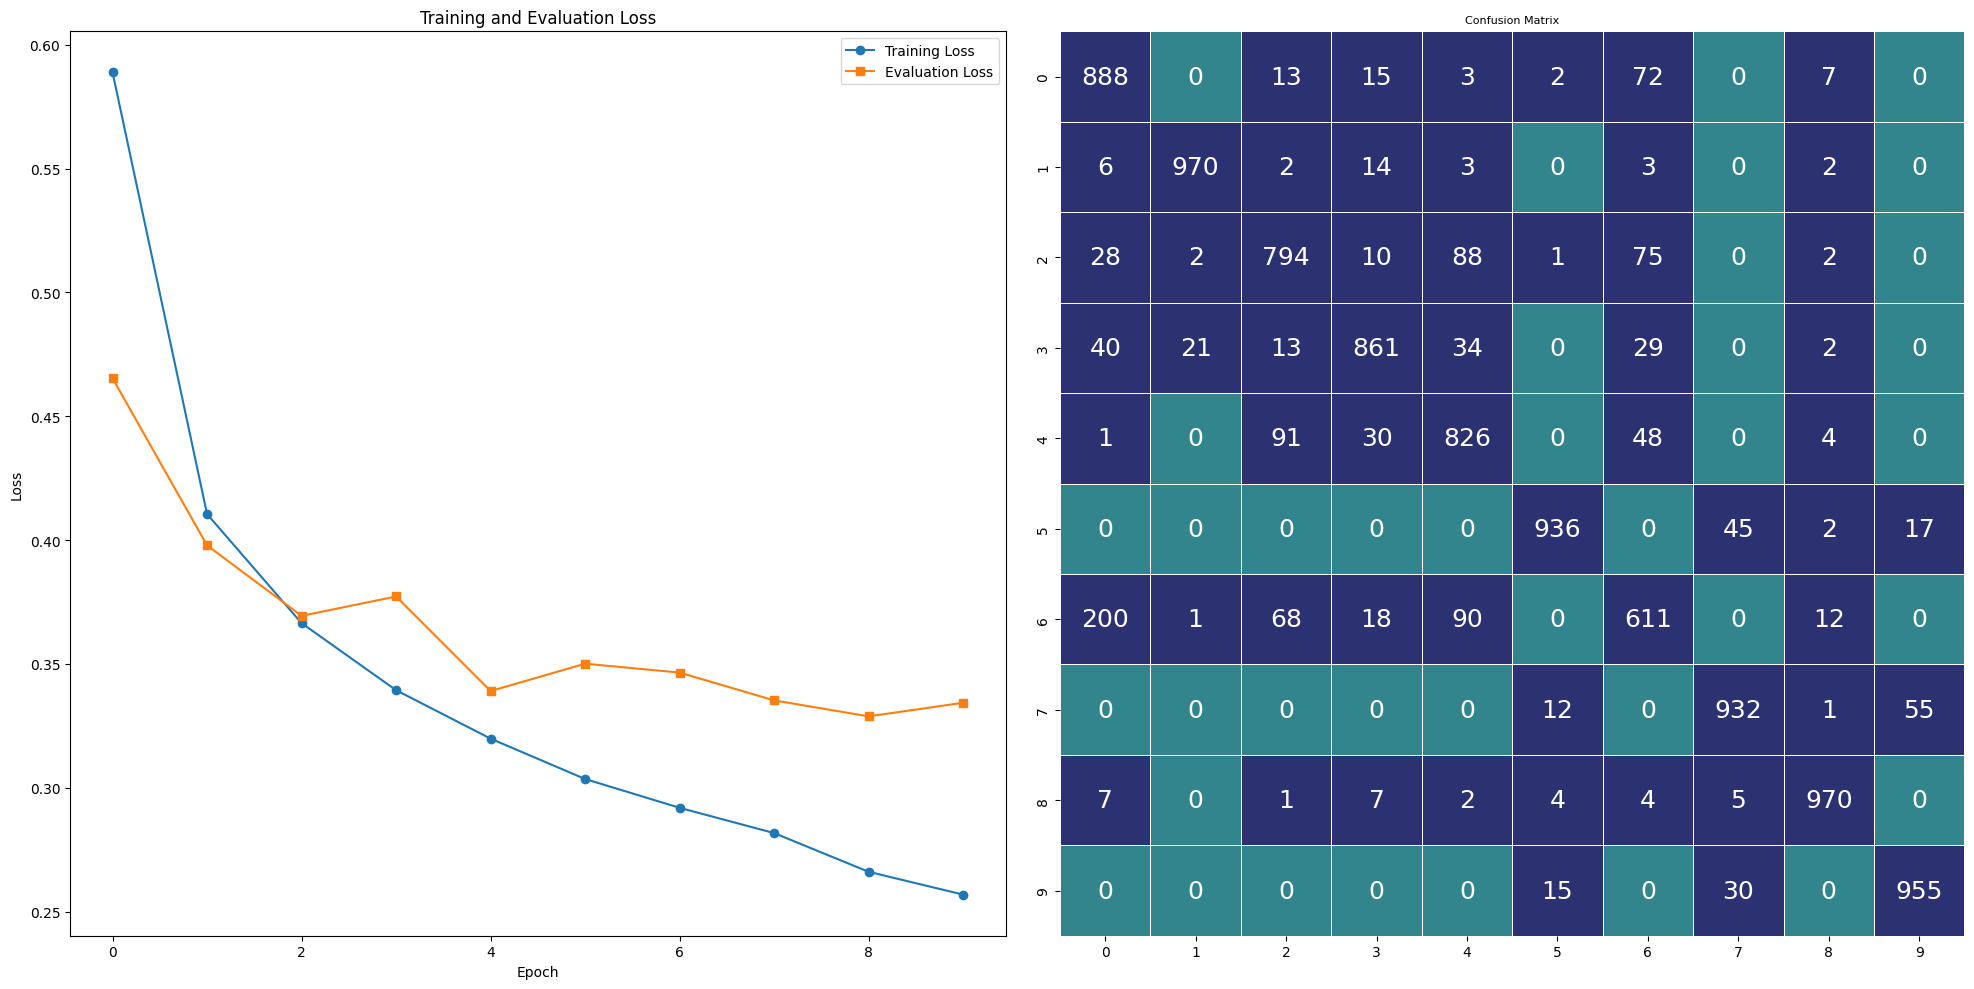

In [206]:
plot_train_eval(deep_train_loss, deep_eval_loss, deep_Adam_cm)

## Wide Model (train, evaluation, test) + Visualization

In [207]:
wide_train_loss, wide_eval_loss = train_and_evaluate(model=wide_model, trainloader=trainloader, valloader=valloader, loss_fn=wide_loss, optimizer=wide_optimizer, device=device, epochs=10)wide_Adam_cm, wide_Adam_acc = testset_prediction(model=wide_model, testloader=testloader, device=device)

Epoch 1/10 - Training: 100%|██████████| 750/750 [00:39<00:00, 19.17it/s]


 ** Training Loss: 0.5154


Epoch 1/10 - Evaluation: 100%|██████████| 188/188 [00:08<00:00, 21.63it/s]


 ** Evaluation Accuracy: 85.05%




Epoch 2/10 - Training: 100%|██████████| 750/750 [00:43<00:00, 17.41it/s]


...

 ** Training Loss: 0.2402


Epoch 10/10 - Evaluation: 100%|██████████| 188/188 [00:08<00:00, 22.41it/s]


 ** Evaluation Accuracy: 88.67%


Train time on cuda: 8.338 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:06<00:00, 22.89it/s]

Final Test Accuracy: 88.08%


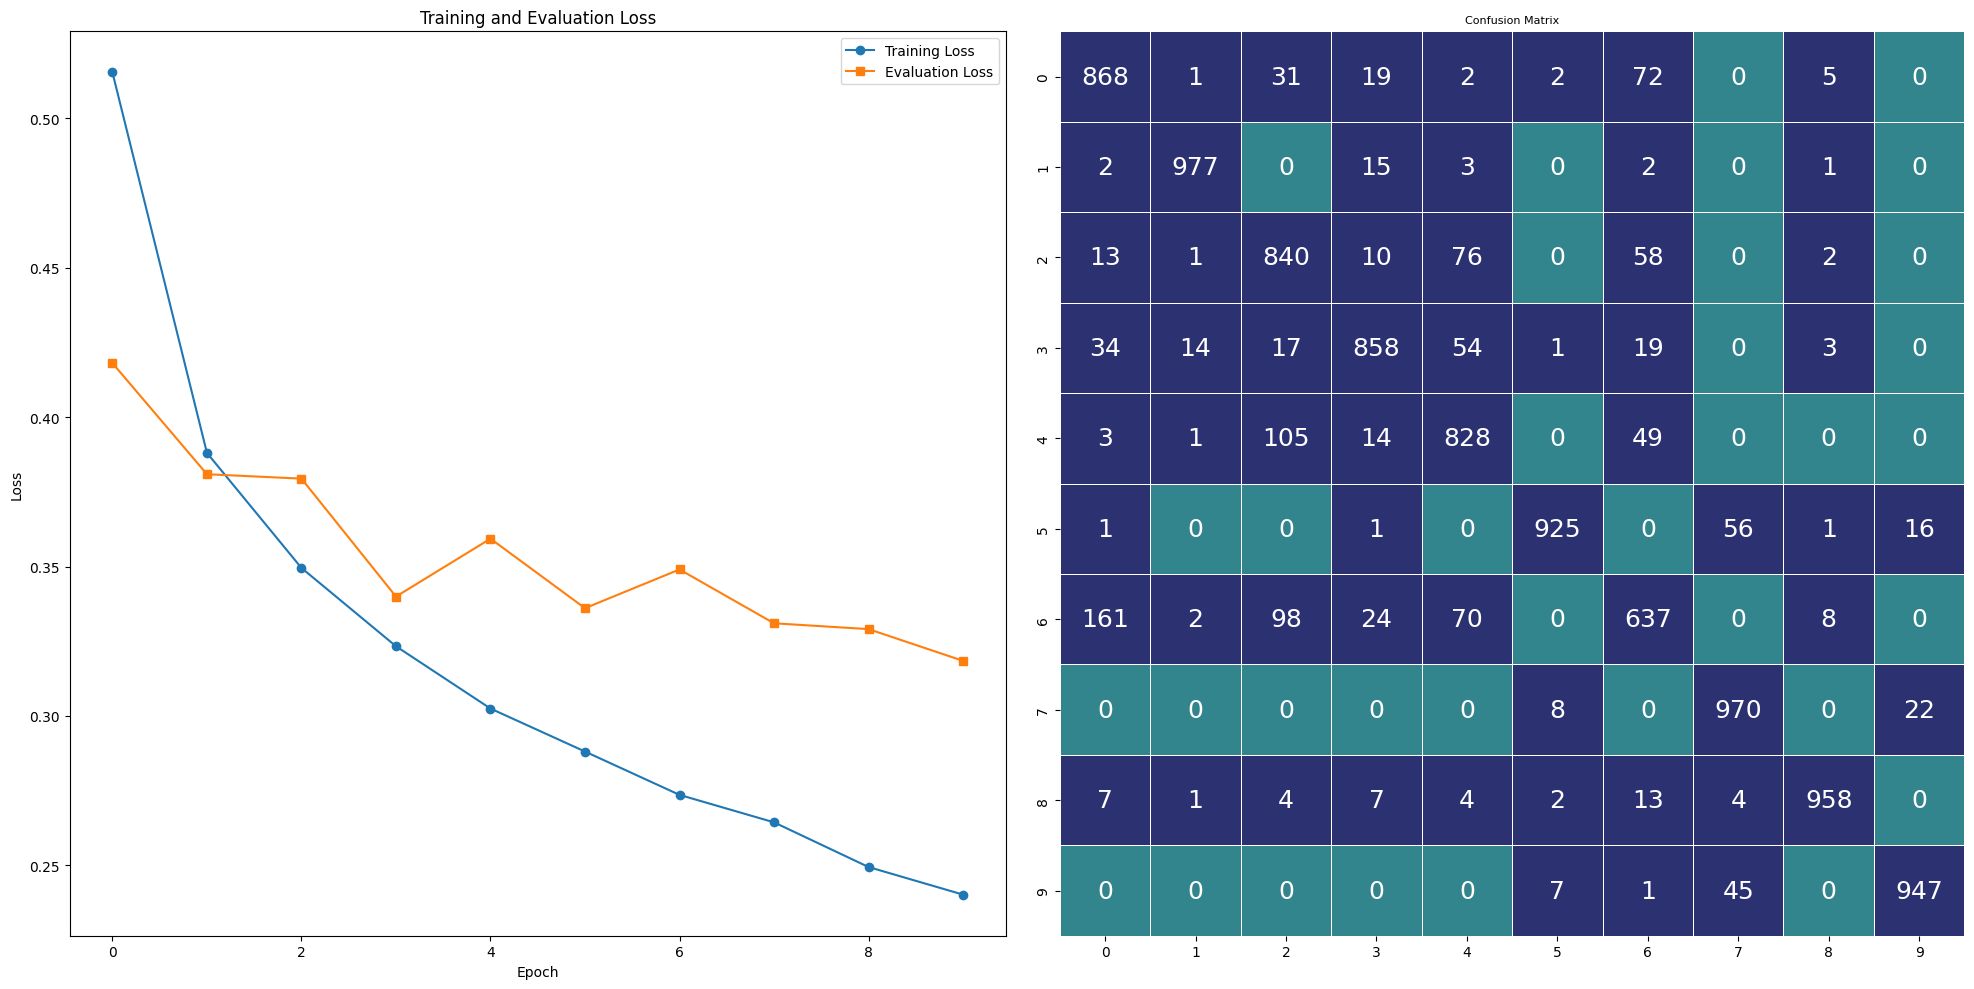

In [208]:
plot_train_eval(wide_train_loss, wide_eval_loss, wide_Adam_cm)

## Deep ("He" & "Xavier" & "Random")

Epoch 1/10 - Training:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 1/10 - Training: 100%|██████████| 750/750 [00:42<00:00, 17.59it/s]


 ** Training Loss: 0.5289


Epoch 1/10 - Evaluation: 100%|██████████| 188/188 [00:09<00:00, 20.06it/s]


 ** Evaluation Accuracy: 83.13%




...

 ** Training Loss: 110.1957


Epoch 10/10 - Evaluation: 100%|██████████| 188/188 [00:10<00:00, 18.33it/s]


 ** Evaluation Accuracy: 75.12%


Train time on cuda: 9.114 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:08<00:00, 18.57it/s]


Final Test Accuracy: 74.49%
Deep Neural Network ('He' weight initialization algorithm)


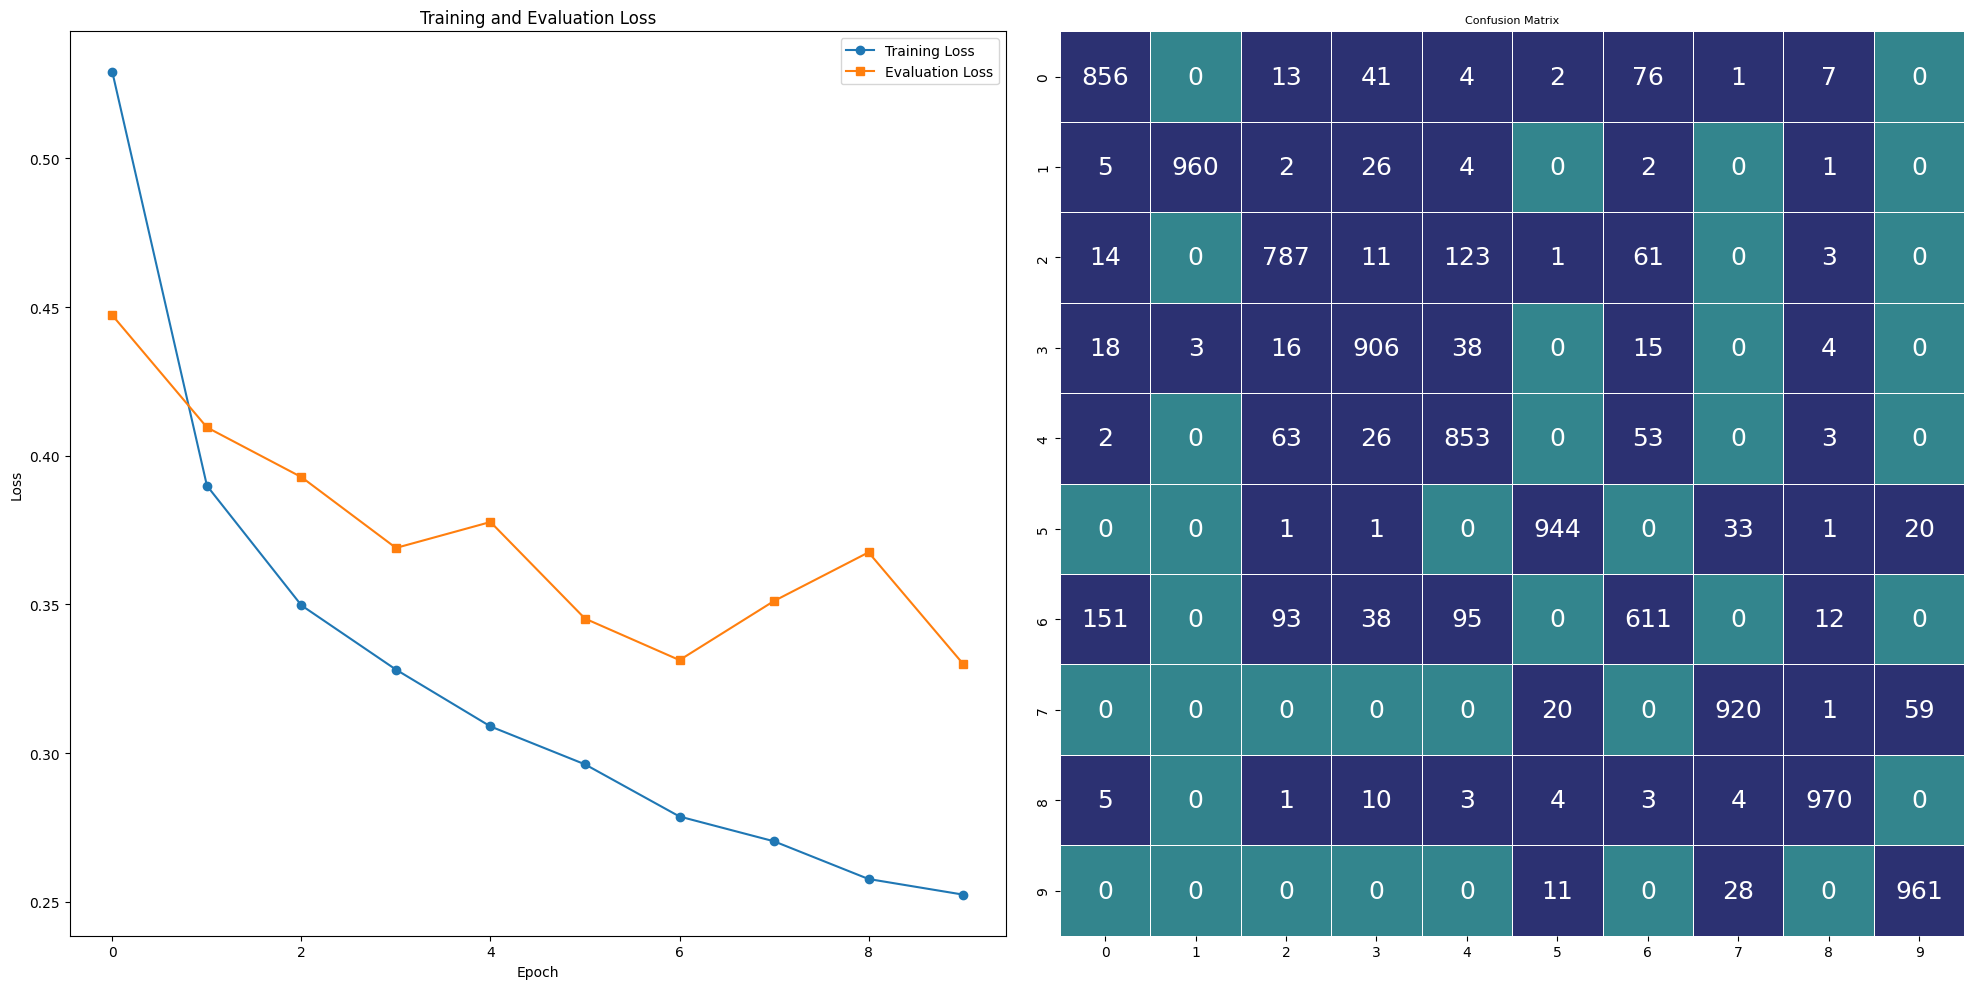

Deep Neural Network ('Xavier' weight initialization algorithm)


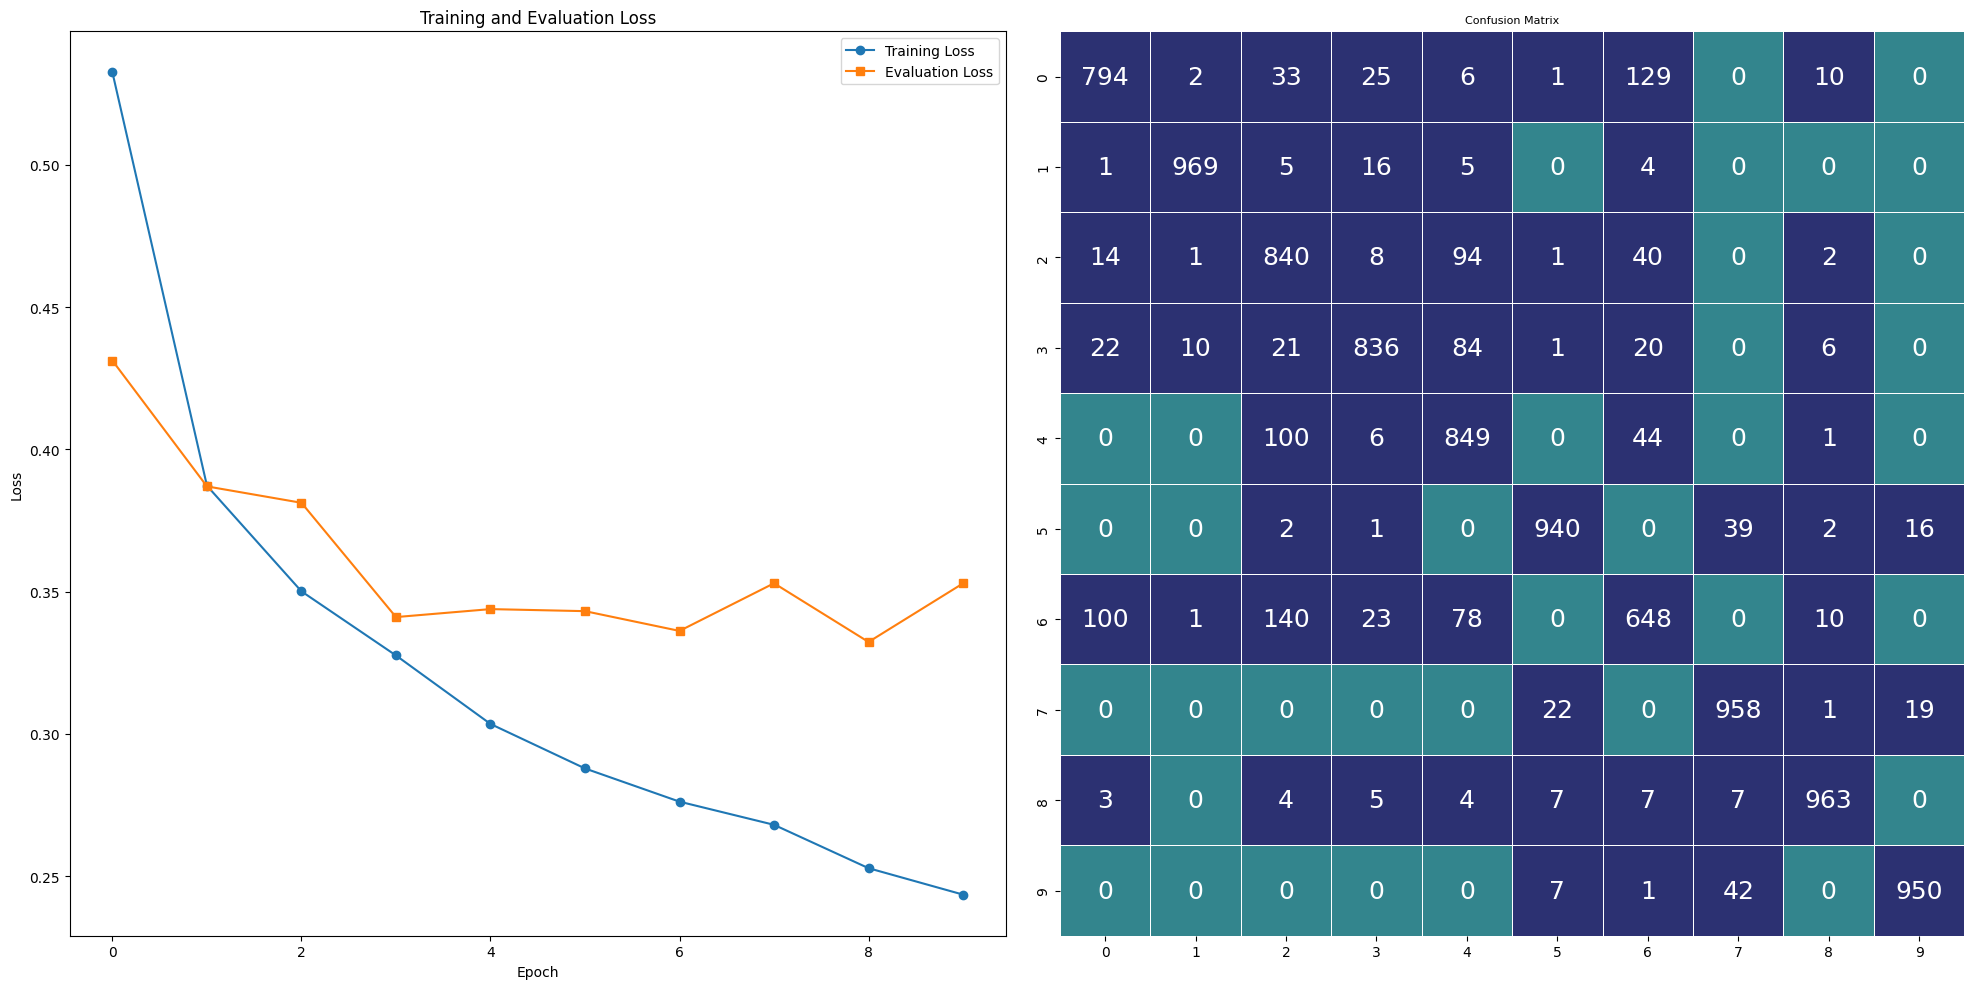

Deep Neural Network ('Random' weight initialization algorithm)


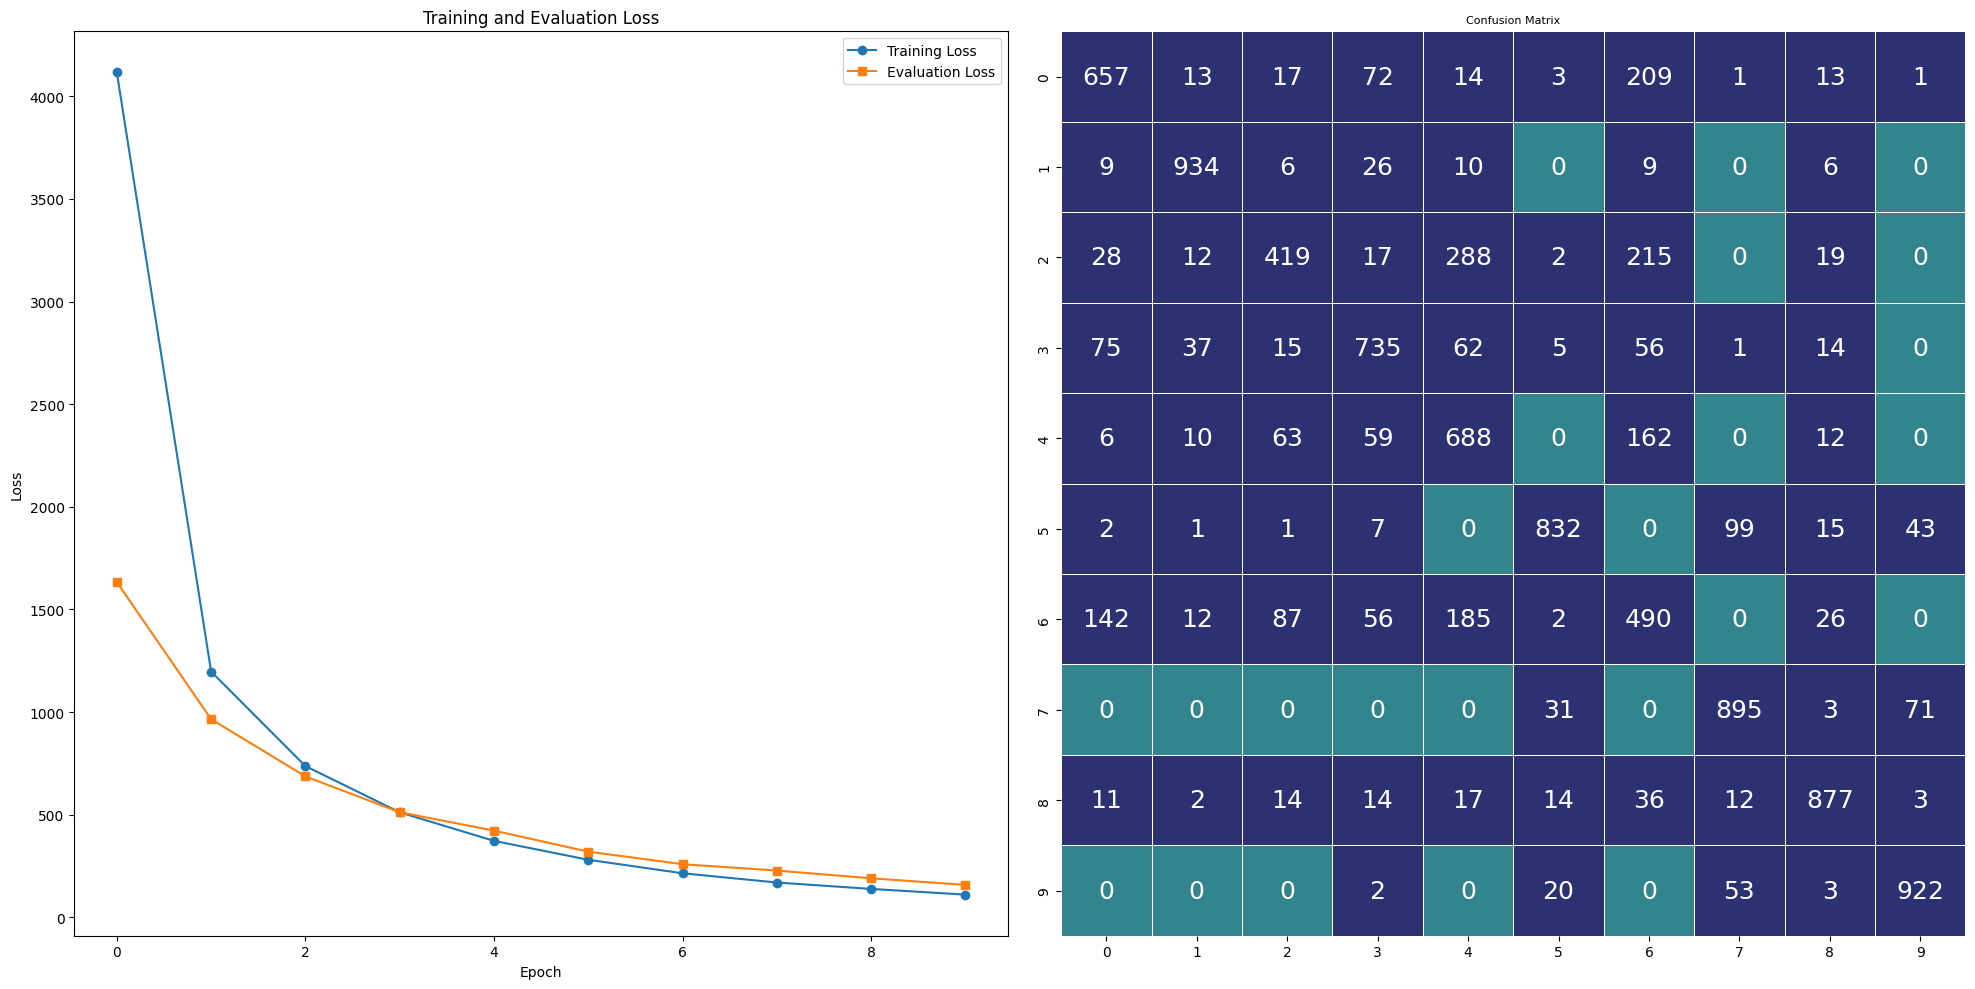

In [214]:
# Hedeep_model_he = DeepNN(init_method='he').to(device)deep_optimizer = torch.optim.Adam(deep_model_he.parameters(), lr=0.001)deep_he_train_loss, deep_he_eval_loss = train_and_evaluate(deep_model_he, trainloader, valloader, deep_loss, deep_optimizer, device, epochs=10)deep_he_cm, deep_he_acc = testset_prediction(deep_model_he, testloader, device)# Xavierdeep_model_xavier = DeepNN(init_method='xavier').to(device)deep_optimizer = torch.optim.Adam(deep_model_xavier.parameters(), lr=0.001)deep_Xavier_train_loss, deep_Xavier_eval_loss = train_and_evaluate(deep_model_xavier, trainloader, valloader, deep_loss, deep_optimizer, device, epochs=10)deep_Xavier_cm, deep_Xavier_acc = testset_prediction(deep_model_xavier, testloader, device)# Randomdeep_model_random = DeepNN(init_method='random').to(device)deep_optimizer = torch.optim.Adam(deep_model_random.parameters(), lr=0.001)deep_random_train_loss, deep_random_eval_loss = train_and_evaluate(deep_model_random, trainloader, valloader, deep_loss, deep_optimizer, device, epochs=10)deep_random_cm, deep_random_acc = testset_prediction(deep_model_random, testloader, device)print("Deep Neural Network ('He' weight initialization algorithm)")plot_train_eval(deep_he_train_loss, deep_he_eval_loss, deep_he_cm)print("Deep Neural Network ('Xavier' weight initialization algorithm)")plot_train_eval(deep_Xavier_train_loss, deep_Xavier_eval_loss, deep_Xavier_cm)print("Deep Neural Network ('Random' weight initialization algorithm)")plot_train_eval(deep_random_train_loss, deep_random_eval_loss, deep_random_cm)

## Wide ("He" & "Xavier" & "Random")

Epoch 1/10 - Training:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 1/10 - Training: 100%|██████████| 750/750 [00:45<00:00, 16.35it/s]


 ** Training Loss: 0.5101


Epoch 1/10 - Evaluation: 100%|██████████| 188/188 [00:09<00:00, 18.98it/s]


 ** Evaluation Accuracy: 84.88%




...

 ** Training Loss: 1.9546


Epoch 10/10 - Evaluation: 100%|██████████| 188/188 [00:09<00:00, 19.95it/s]


 ** Evaluation Accuracy: 80.08%


Train time on cuda: 8.928 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:07<00:00, 21.93it/s]


Final Test Accuracy: 79.67%
Wide Neural Network ('He' weight initialization algorithm)


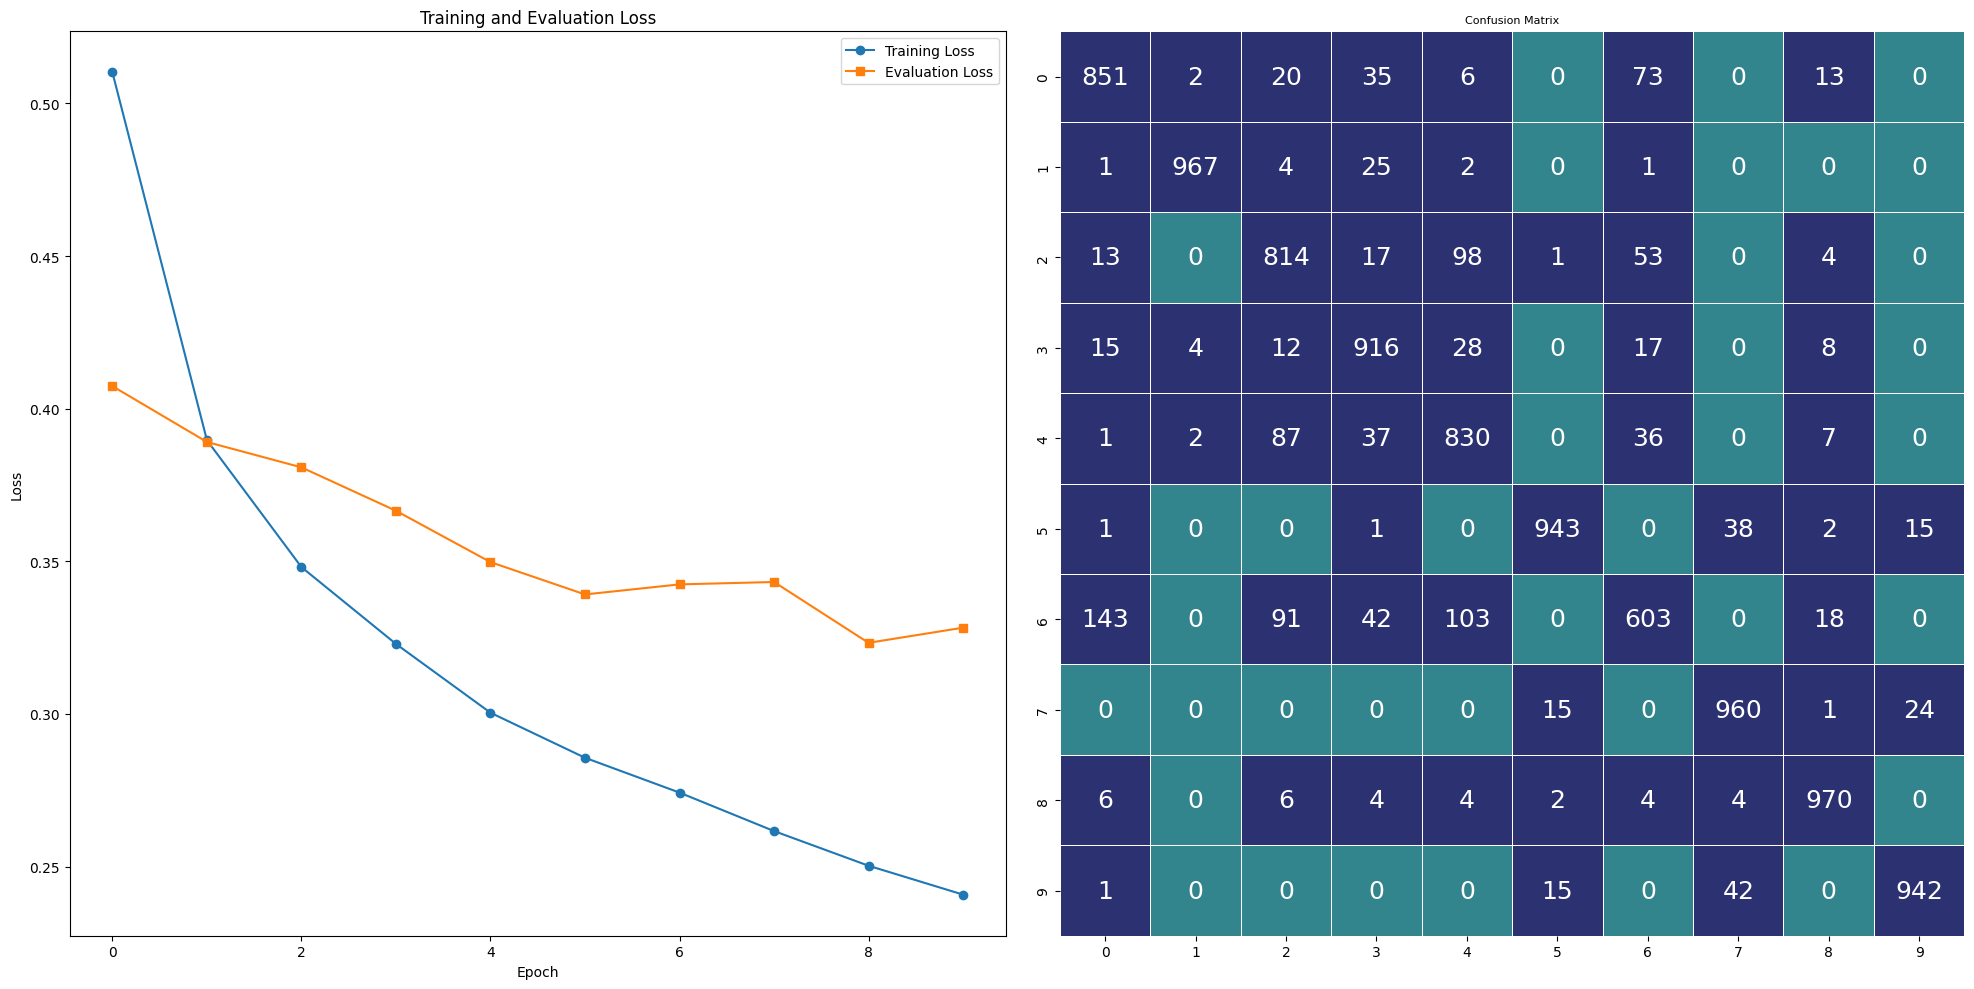

Wide Neural Network ('Xavier' weight initialization algorithm)


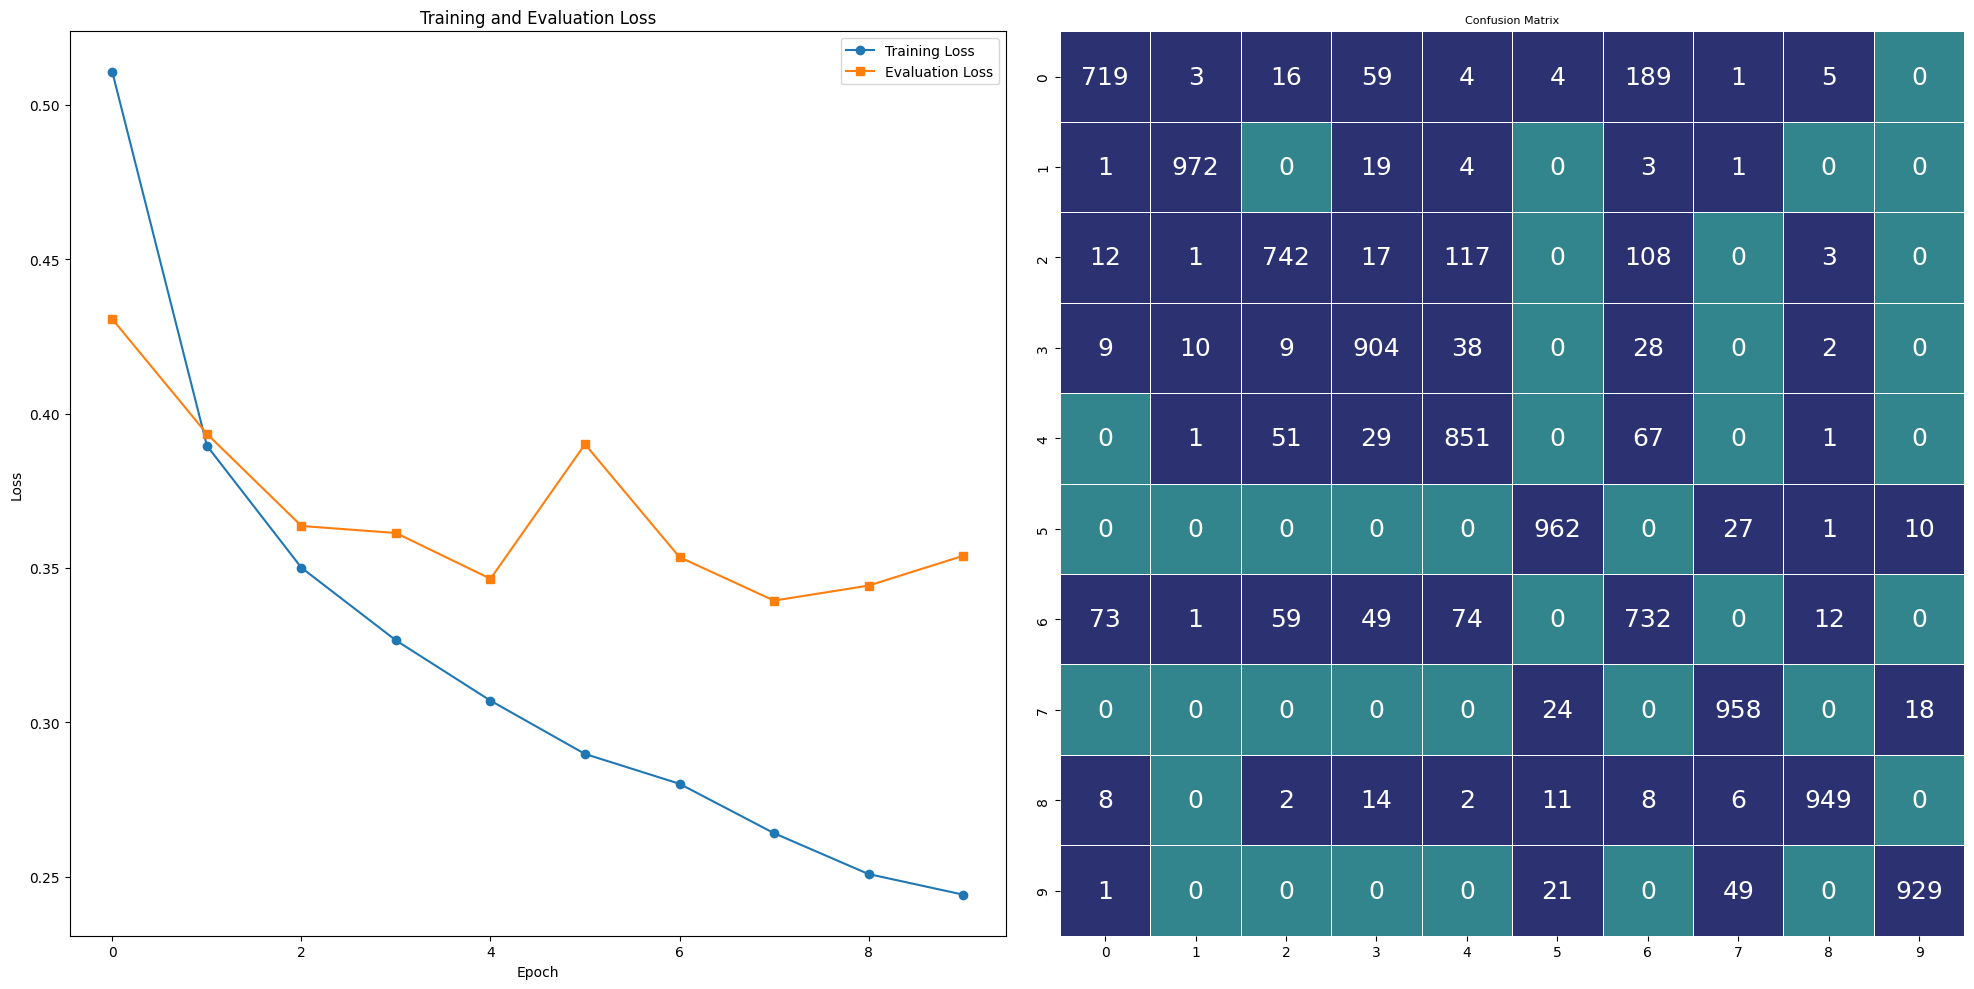

Wide Neural Network ('Random' weight initialization algorithm)


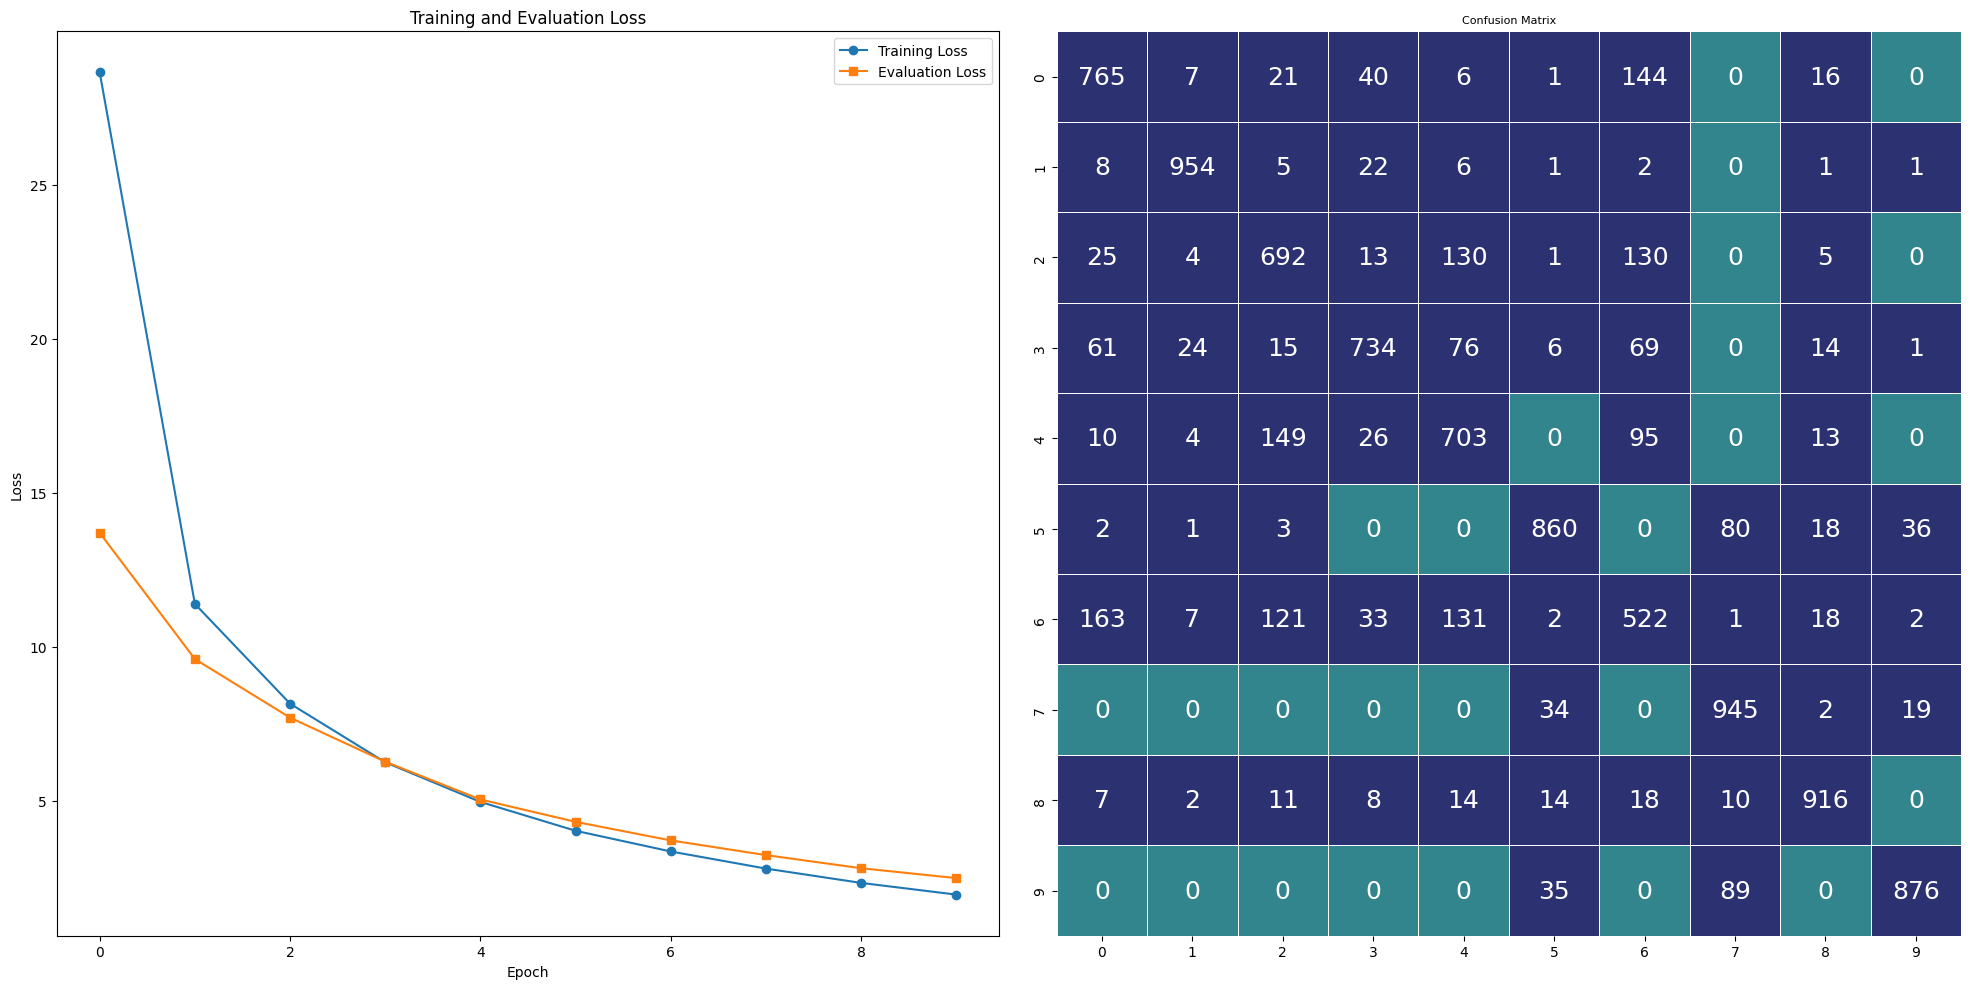

In [215]:
# Hewide_model_he = WideNN(init_method='he').to(device)wide_optimizer = torch.optim.Adam(wide_model_he.parameters(), lr=0.001)wide_he_train_loss, wide_he_eval_loss = train_and_evaluate(wide_model_he, trainloader, valloader, wide_loss, wide_optimizer, device, epochs=10)wide_he_cm, wide_he_acc = testset_prediction(wide_model_he, testloader, device)# Xavierwide_model_xavier = WideNN(init_method='xavier').to(device)wide_optimizer = torch.optim.Adam(wide_model_xavier.parameters(), lr=0.001)wide_Xavier_train_loss, wide_Xavier_eval_loss = train_and_evaluate(wide_model_xavier, trainloader, valloader, wide_loss, wide_optimizer, device, epochs=10)wide_Xavier_cm, wide_Xavier_acc = testset_prediction(wide_model_xavier, testloader, device)# Randomwide_model_random = WideNN(init_method='random').to(device)wide_optimizer = torch.optim.Adam(wide_model_random.parameters(), lr=0.001)wide_random_train_loss, wide_random_eval_loss = train_and_evaluate(wide_model_random, trainloader, valloader, wide_loss, wide_optimizer, device, epochs=10)wide_random_cm, wide_random_acc = testset_prediction(wide_model_random, testloader, device)print("Wide Neural Network ('He' weight initialization algorithm)")plot_train_eval(wide_he_train_loss, wide_he_eval_loss, wide_he_cm)print("Wide Neural Network ('Xavier' weight initialization algorithm)")plot_train_eval(wide_Xavier_train_loss, wide_Xavier_eval_loss, wide_Xavier_cm)print("Wide Neural Network ('Random' weight initialization algorithm)")plot_train_eval(wide_random_train_loss, wide_random_eval_loss, wide_random_cm)

In [216]:
compare_table = {    'DeepNN': [deep_he_acc, deep_Xavier_acc, deep_random_acc],    'WideNN': [wide_he_acc, wide_Xavier_acc, wide_random_acc]}# Create a DataFramecompare_table = pd.DataFrame(compare_table, index=['He', 'Xavier', 'Random'])compare_table

,DeepNN,WideNN
He,87.68,87.96
Xavier,87.47,87.18
Random,74.49,79.67


## Q3.1 learning rates

In [222]:
def learning_rate_init(deep:bool):    accuracy_dict = {}    learning_rates = [1.0, 0.1, 0.01, 0.001]    loss = nn.CrossEntropyLoss()    for learning_rate in learning_rates:        if deep:            model = DeepNN().to(device)        else:            model = WideNN().to(device)        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)        print(f"** learning rate: {learning_rate}:")        train_losses, eval_losses = train_and_evaluate(model, trainloader, valloader, loss, optimizer, device, epochs=5)        conf_matrix, accuracy = testset_prediction(model, testloader, device)        print(f'Deep Neural Network (learning rate: {learning_rate})' if deep else f'Wide Neural Network (learning rate: {learning_rate})')        plot_train_eval(train_losses, eval_losses, conf_matrix)        accuracy_dict[learning_rate] = accuracy    return accuracy_dict

training the 'Deep Neural Network': 
** learning rate: 1.0:


Epoch 1/5 - Training:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 1/5 - Training: 100%|██████████| 750/750 [00:52<00:00, 14.26it/s]


 ** Training Loss: 60033.9094


Epoch 1/5 - Evaluation: 100%|██████████| 188/188 [00:09<00:00, 20.56it/s]


...

 ** Training Loss: 2.3756


Epoch 5/5 - Evaluation: 100%|██████████| 188/188 [00:21<00:00,  8.89it/s]


 ** Evaluation Accuracy: 10.00%


Train time on cuda: 5.712 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:16<00:00,  9.79it/s]


Final Test Accuracy: 10.00%
Deep Neural Network (learning rate: 1.0)


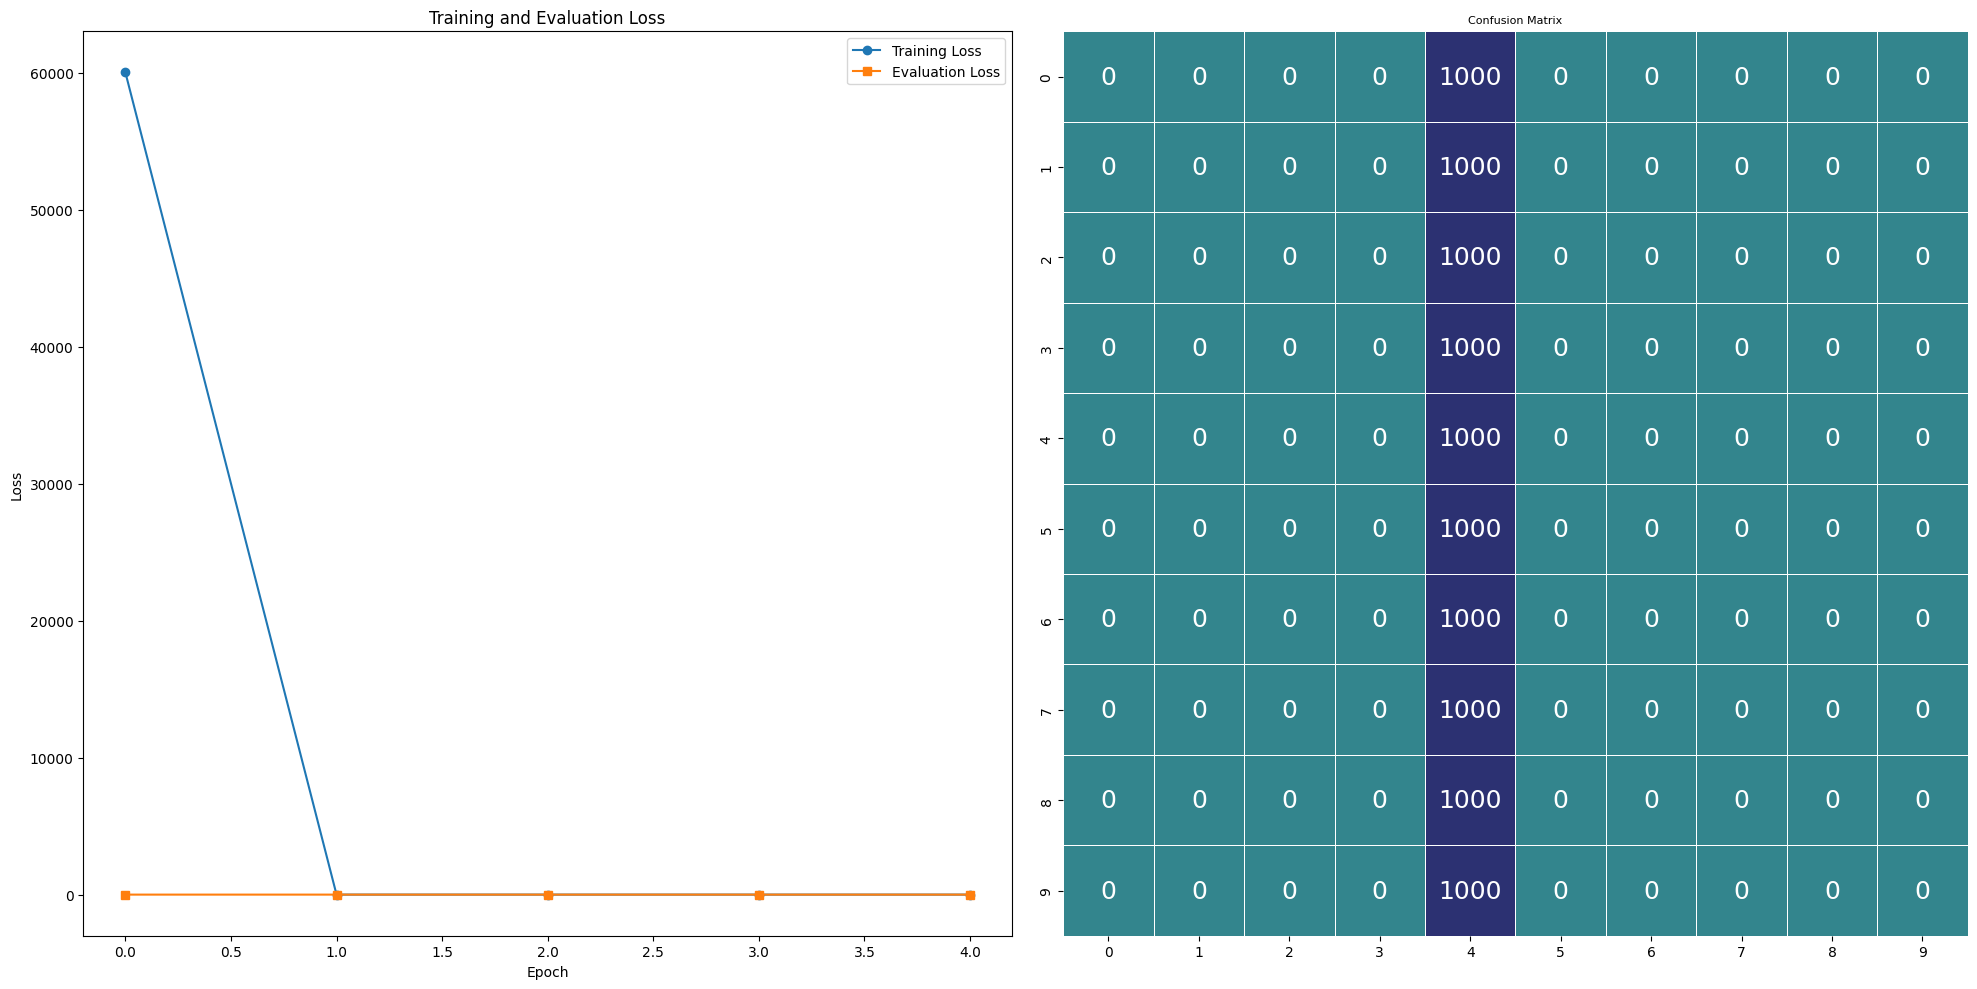

** learning rate: 0.1:


Epoch 1/5 - Training: 100%|██████████| 750/750 [00:53<00:00, 13.92it/s]


 ** Training Loss: 5.1602


Epoch 1/5 - Evaluation: 100%|██████████| 188/188 [00:09<00:00, 19.97it/s]


 ** Evaluation Accuracy: 9.99%




...

 ** Training Loss: 2.3108


Epoch 5/5 - Evaluation: 100%|██████████| 188/188 [00:10<00:00, 18.31it/s]


 ** Evaluation Accuracy: 9.78%


Train time on cuda: 4.959 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:08<00:00, 19.53it/s]


Final Test Accuracy: 10.00%
Deep Neural Network (learning rate: 0.1)


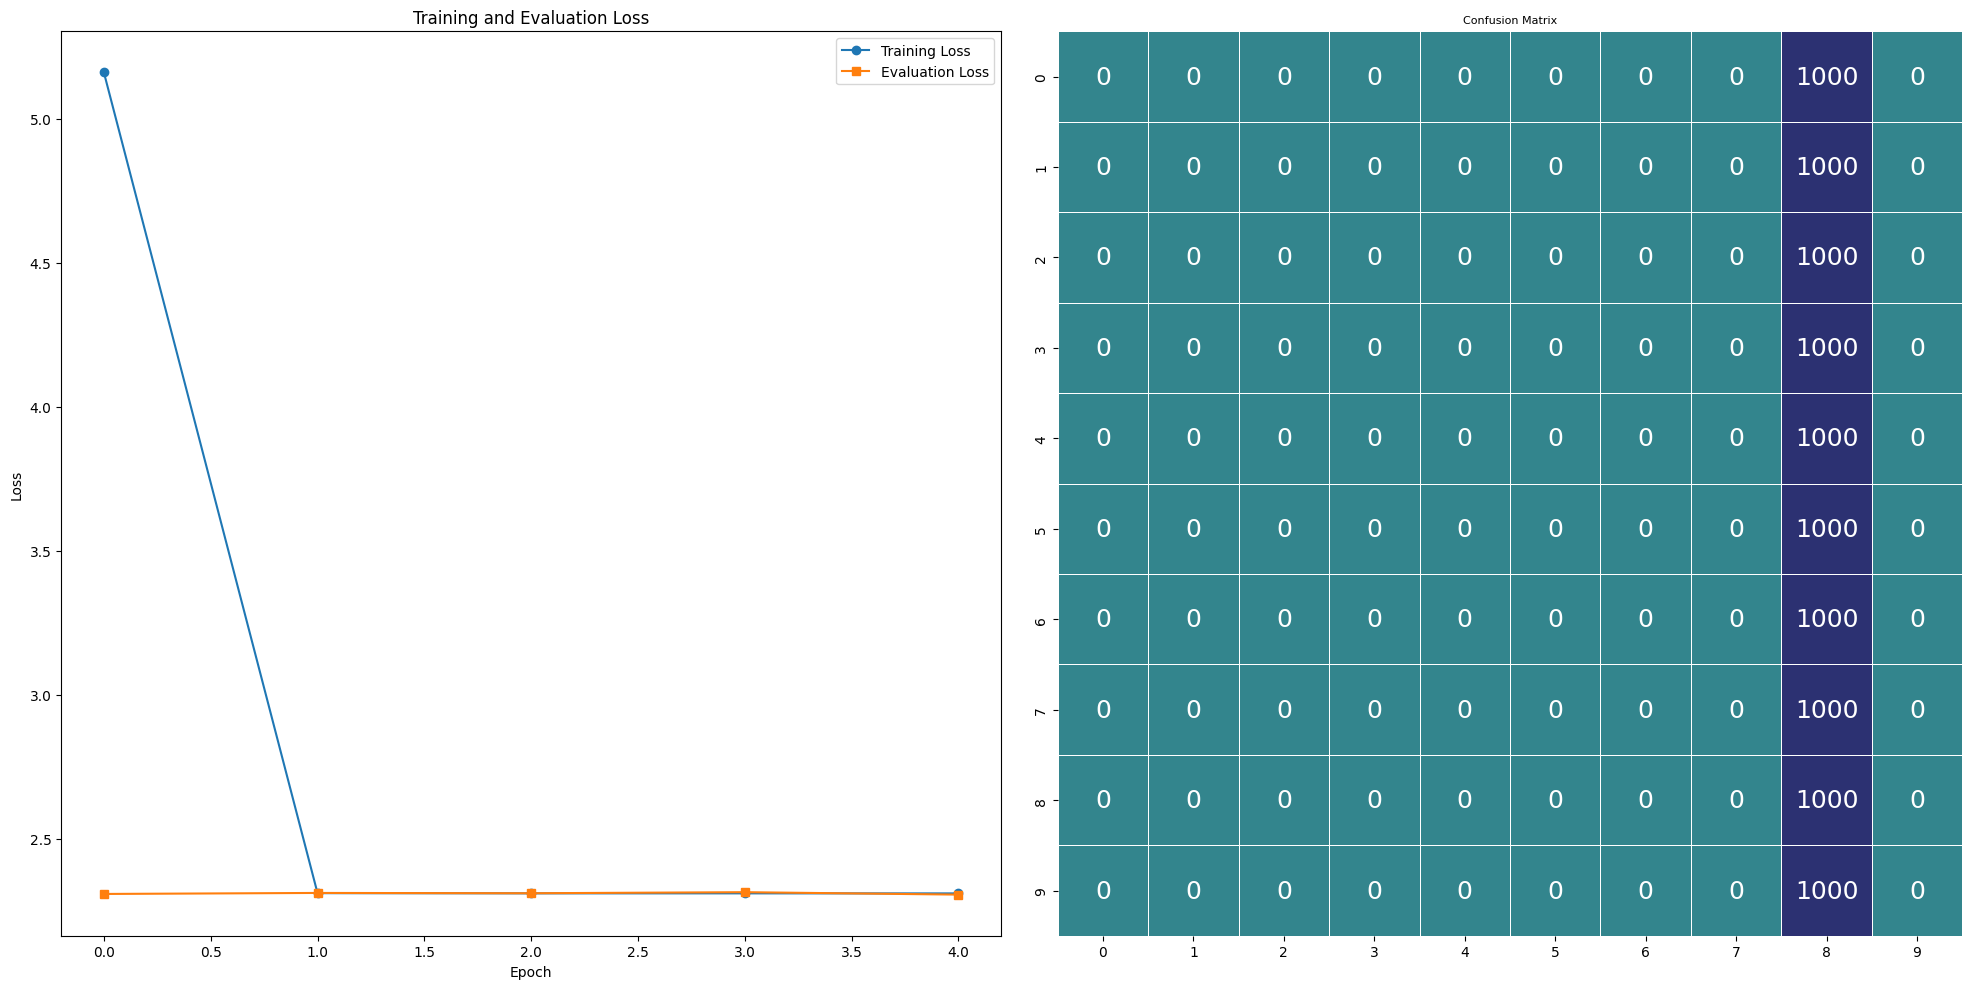

** learning rate: 0.01:


Epoch 1/5 - Training: 100%|██████████| 750/750 [00:50<00:00, 14.89it/s]


 ** Training Loss: 0.6519


Epoch 1/5 - Evaluation: 100%|██████████| 188/188 [00:12<00:00, 15.12it/s]


 ** Evaluation Accuracy: 78.89%




...

 ** Training Loss: 0.4290


Epoch 5/5 - Evaluation: 100%|██████████| 188/188 [00:09<00:00, 20.50it/s]


 ** Evaluation Accuracy: 84.53%


Train time on cuda: 5.147 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:07<00:00, 20.86it/s]


Final Test Accuracy: 84.38%
Deep Neural Network (learning rate: 0.01)


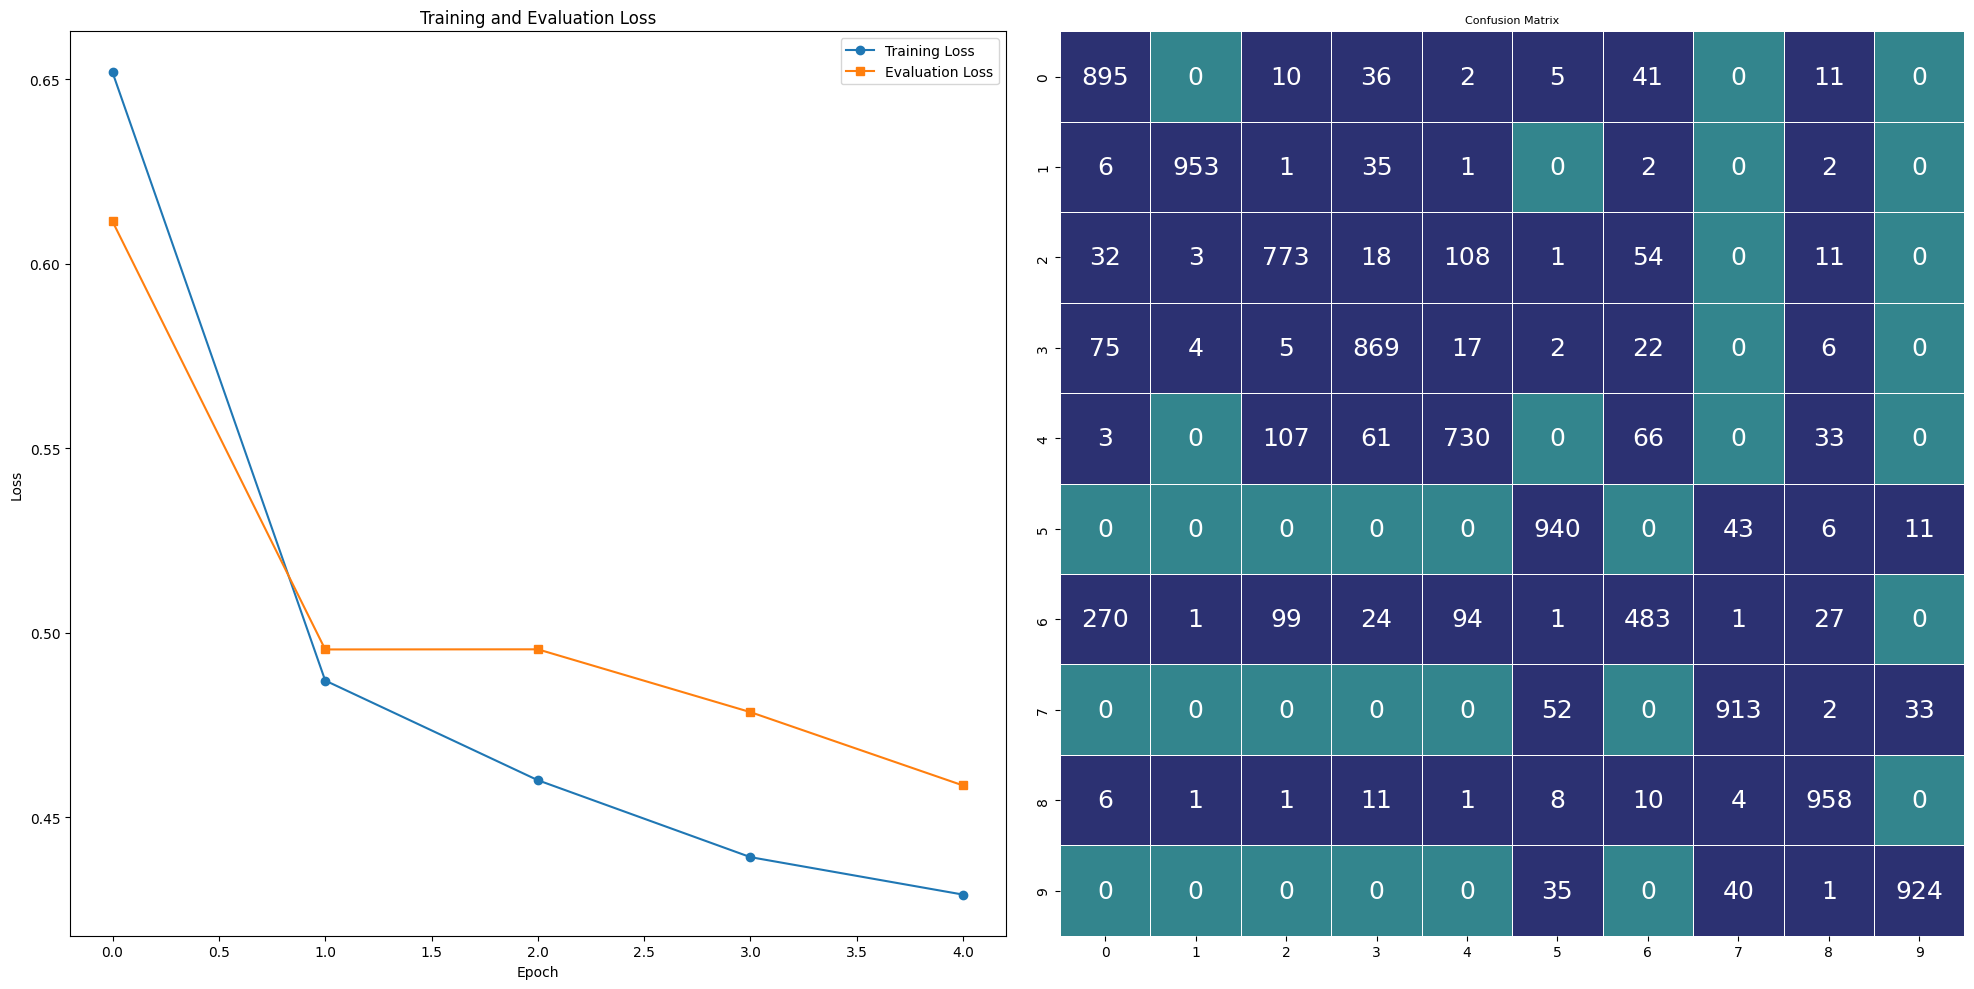

** learning rate: 0.001:


Epoch 1/5 - Training: 100%|██████████| 750/750 [00:51<00:00, 14.63it/s]


 ** Training Loss: 0.5867


Epoch 1/5 - Evaluation: 100%|██████████| 188/188 [00:09<00:00, 19.85it/s]


 ** Evaluation Accuracy: 81.75%




...

 ** Training Loss: 0.3172


Epoch 5/5 - Evaluation: 100%|██████████| 188/188 [00:09<00:00, 20.43it/s]


 ** Evaluation Accuracy: 86.38%


Train time on cuda: 4.683 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:07<00:00, 20.11it/s]


Final Test Accuracy: 86.00%
Deep Neural Network (learning rate: 0.001)


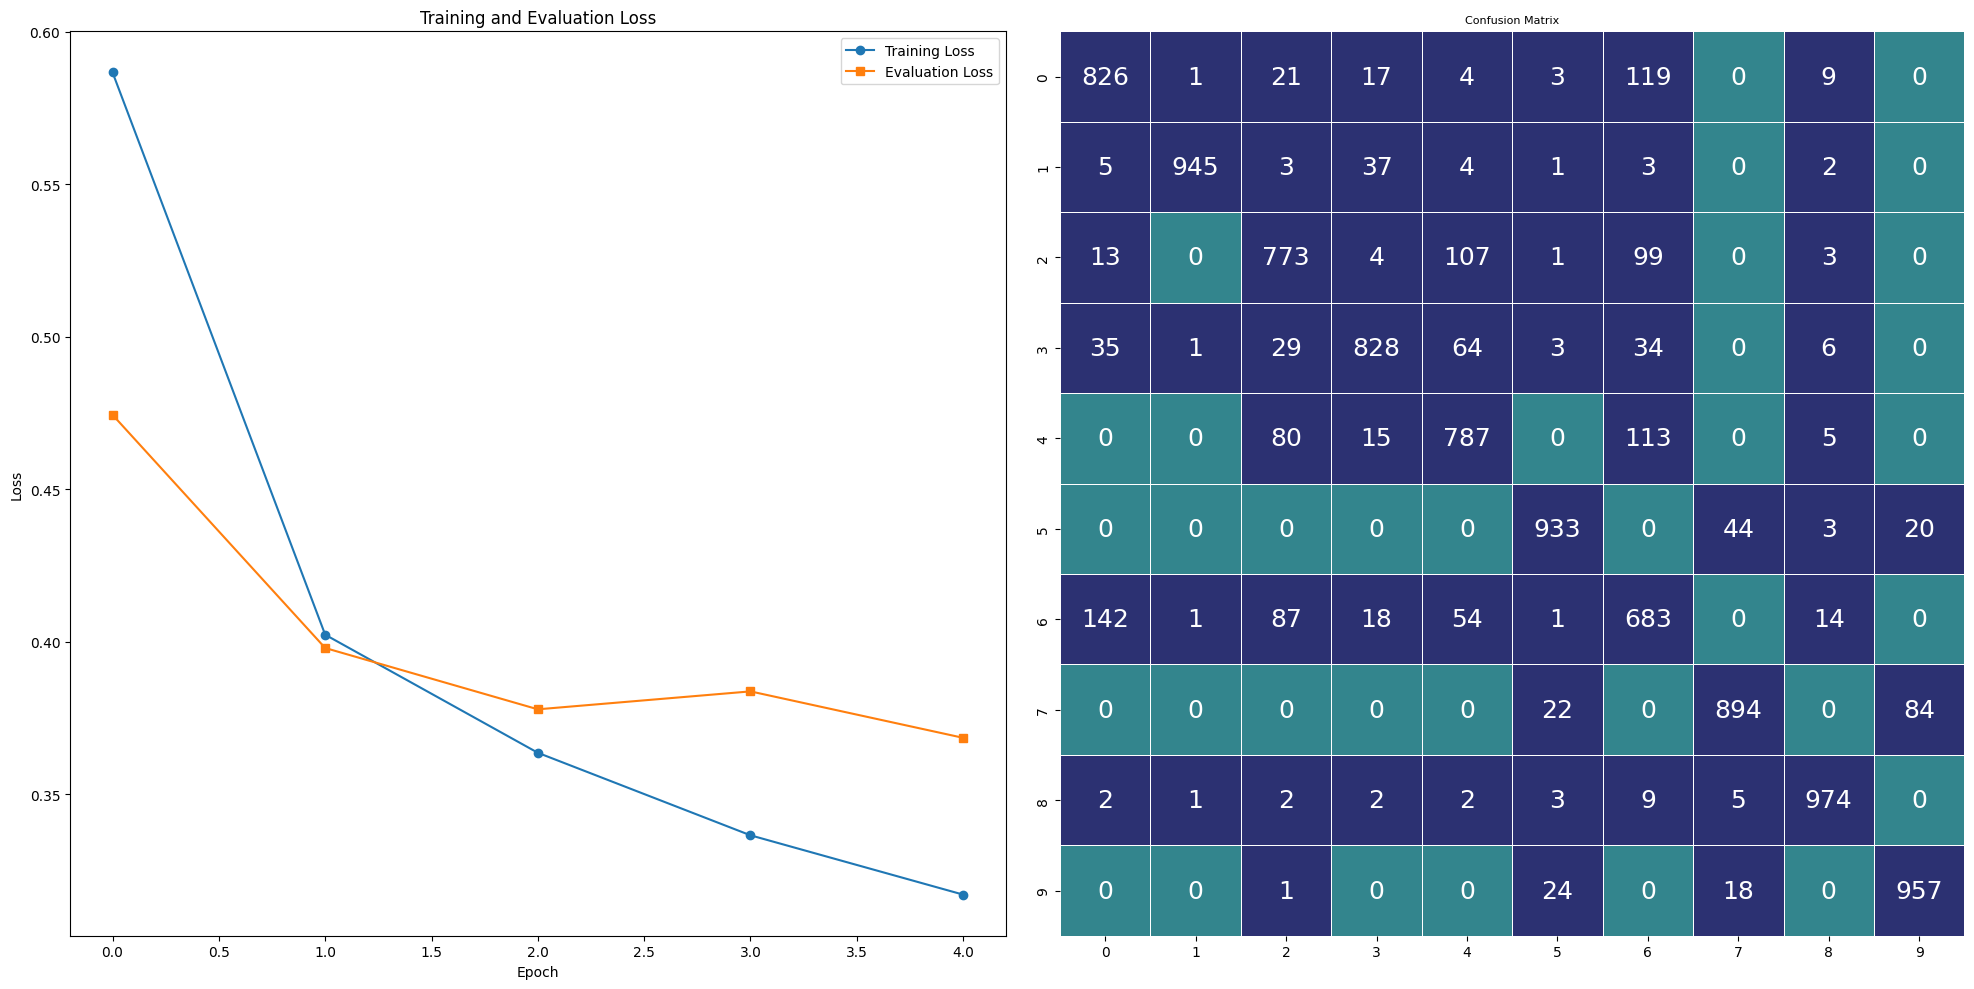

training the 'Wide Neural Network': 
** learning rate: 1.0:


Epoch 1/5 - Training: 100%|██████████| 750/750 [00:44<00:00, 16.72it/s]


 ** Training Loss: 76.7547


Epoch 1/5 - Evaluation: 100%|██████████| 188/188 [00:13<00:00, 14.29it/s]


 ** Evaluation Accuracy: 13.21%




...

 ** Training Loss: 4.2576


Epoch 5/5 - Evaluation: 100%|██████████| 188/188 [00:08<00:00, 21.91it/s]


 ** Evaluation Accuracy: 9.88%


Train time on cuda: 4.180 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:06<00:00, 22.75it/s]


Final Test Accuracy: 10.03%
Wide Neural Network (learning rate: 1.0)


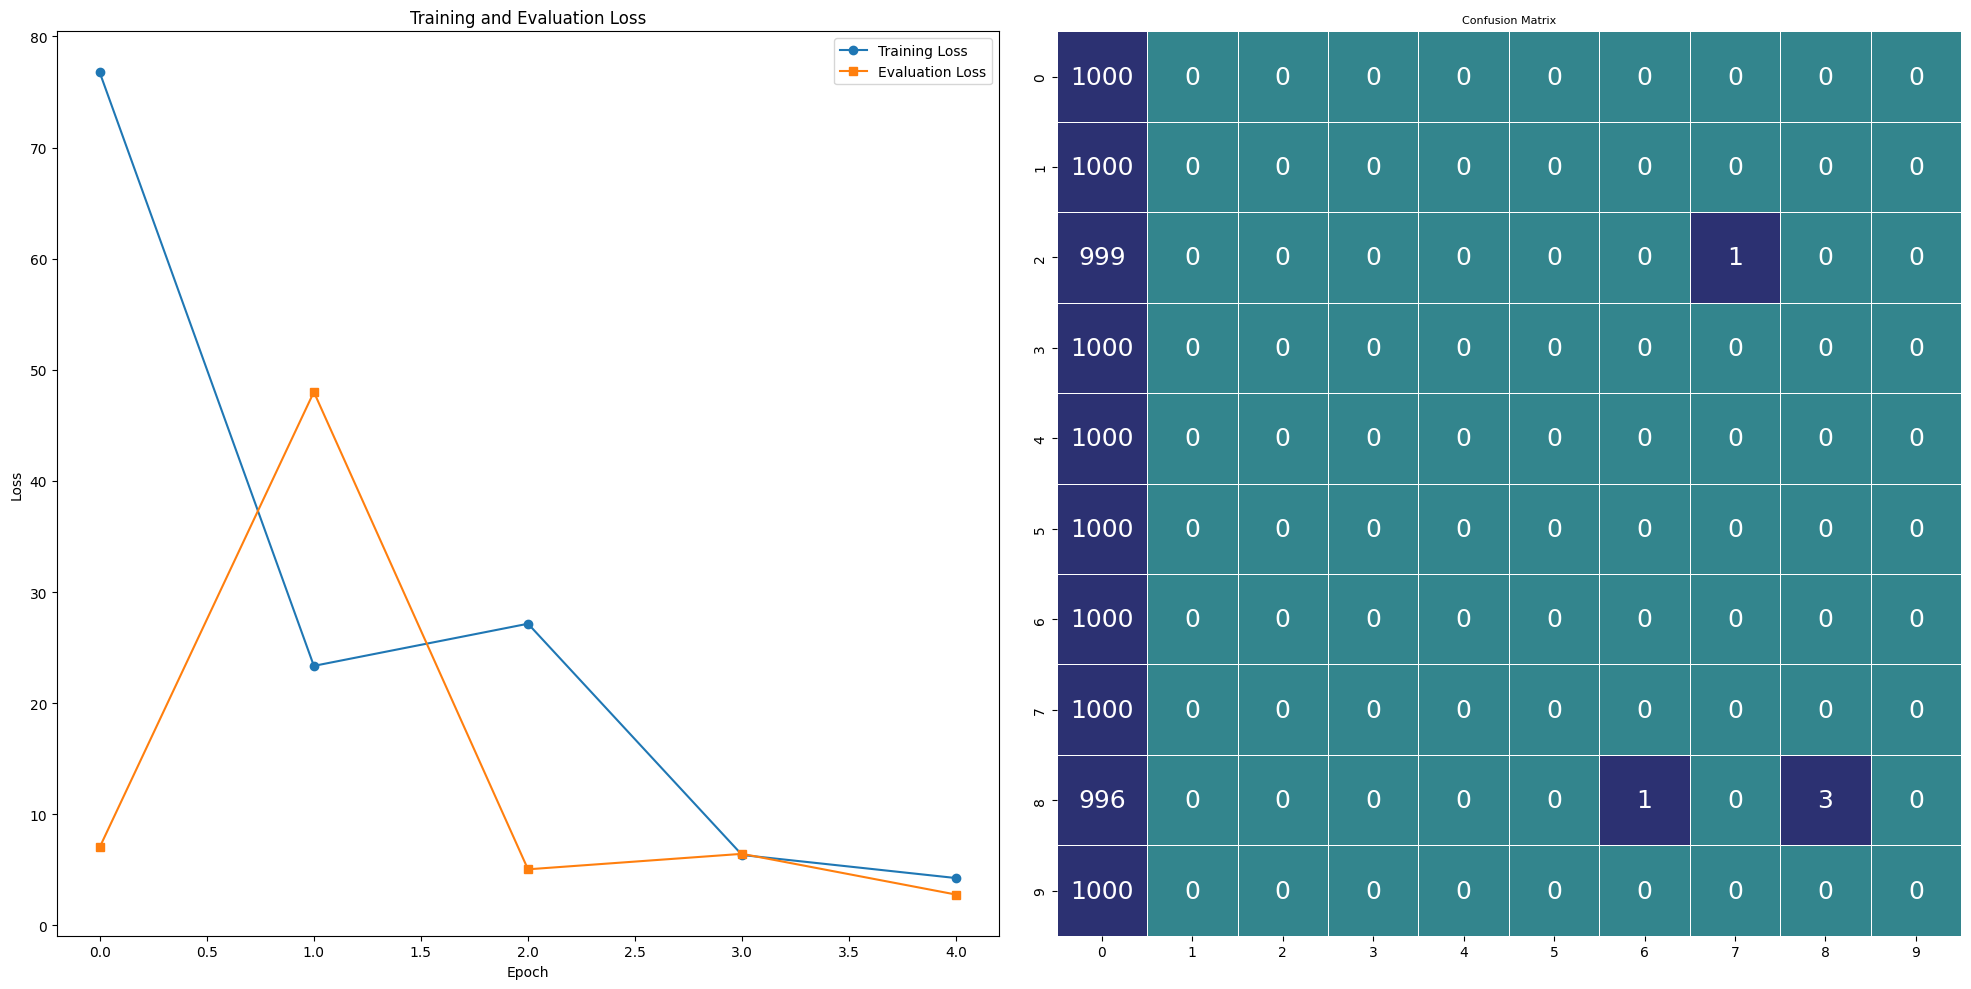

** learning rate: 0.1:


Epoch 1/5 - Training: 100%|██████████| 750/750 [00:40<00:00, 18.69it/s]


 ** Training Loss: 2.8211


Epoch 1/5 - Evaluation: 100%|██████████| 188/188 [00:08<00:00, 21.52it/s]


 ** Evaluation Accuracy: 11.60%




...

 ** Training Loss: 2.4265


Epoch 5/5 - Evaluation: 100%|██████████| 188/188 [00:08<00:00, 22.20it/s]


 ** Evaluation Accuracy: 9.67%


Train time on cuda: 4.124 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:06<00:00, 23.10it/s]


Final Test Accuracy: 10.03%
Wide Neural Network (learning rate: 0.1)


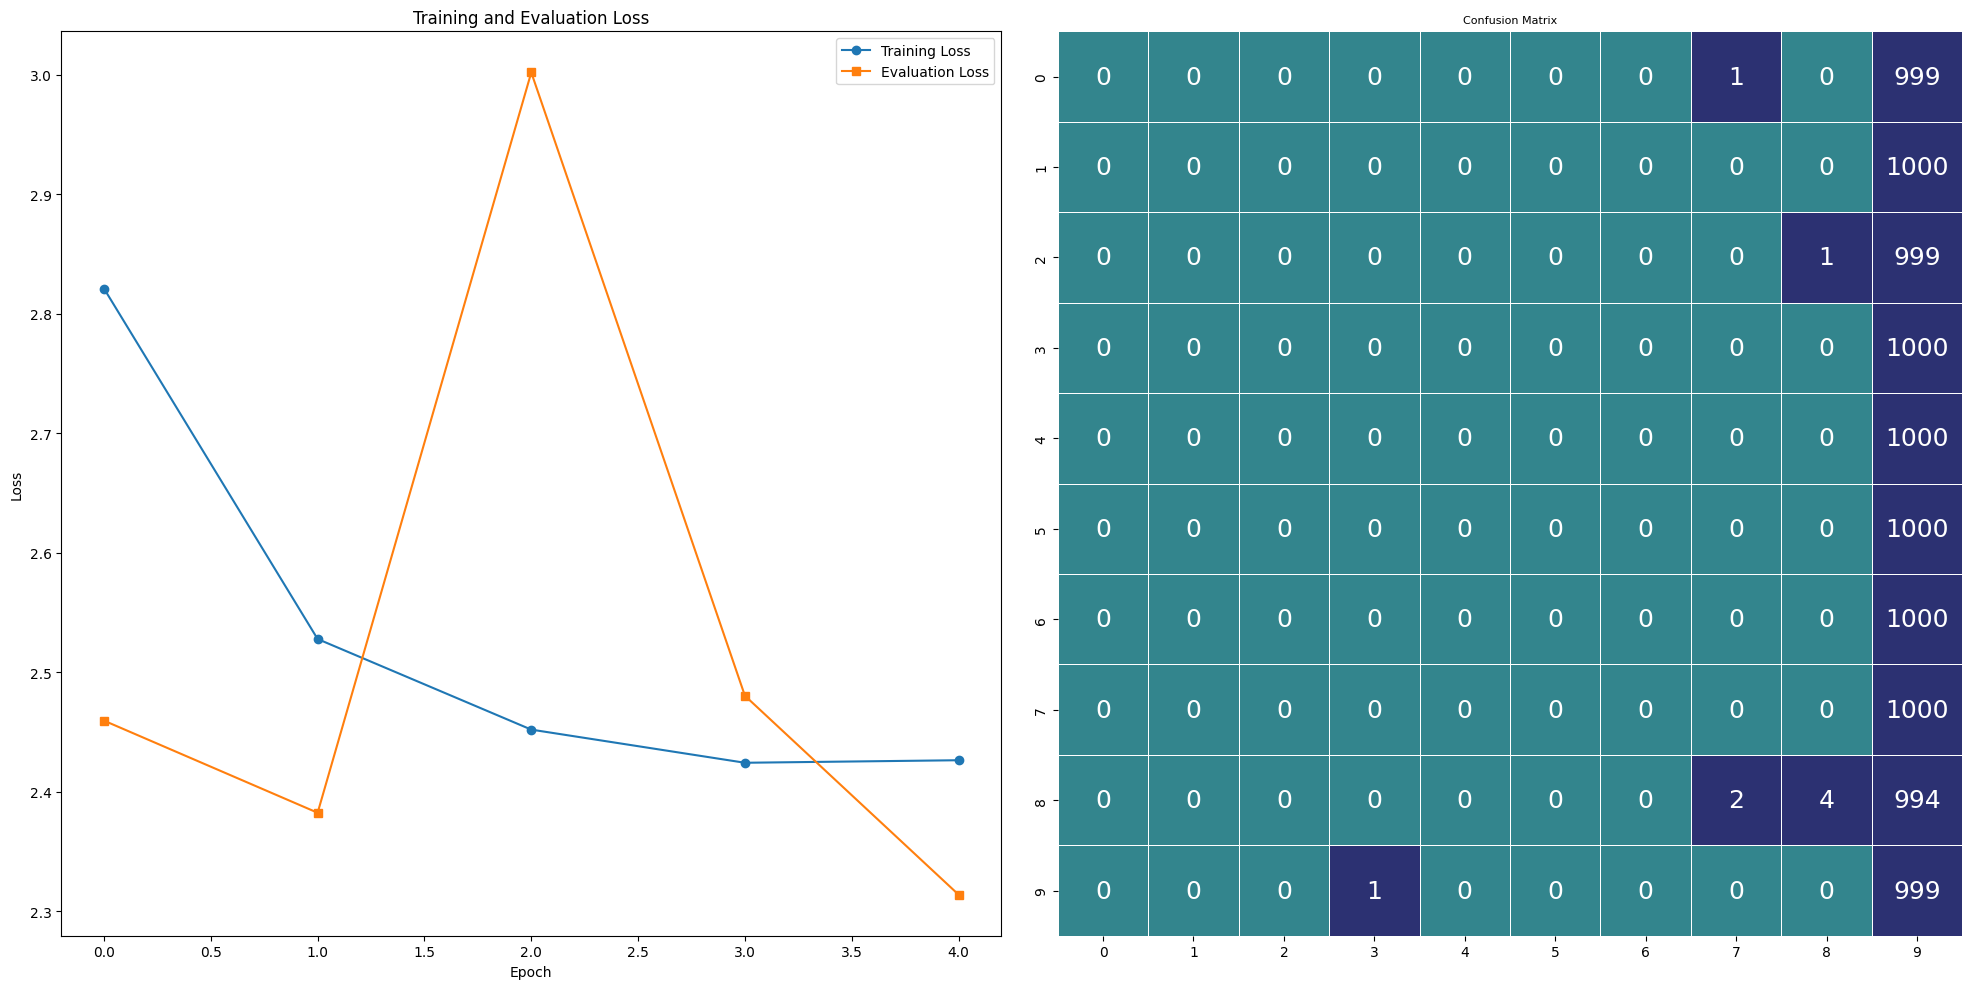

** learning rate: 0.01:


Epoch 1/5 - Training: 100%|██████████| 750/750 [00:40<00:00, 18.67it/s]


 ** Training Loss: 0.5669


Epoch 1/5 - Evaluation: 100%|██████████| 188/188 [00:08<00:00, 22.22it/s]


 ** Evaluation Accuracy: 83.08%




...

 ** Training Loss: 0.4049


Epoch 5/5 - Evaluation: 100%|██████████| 188/188 [00:09<00:00, 20.39it/s]


 ** Evaluation Accuracy: 83.27%


Train time on cuda: 4.044 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:07<00:00, 21.99it/s]


Final Test Accuracy: 82.89%
Wide Neural Network (learning rate: 0.01)


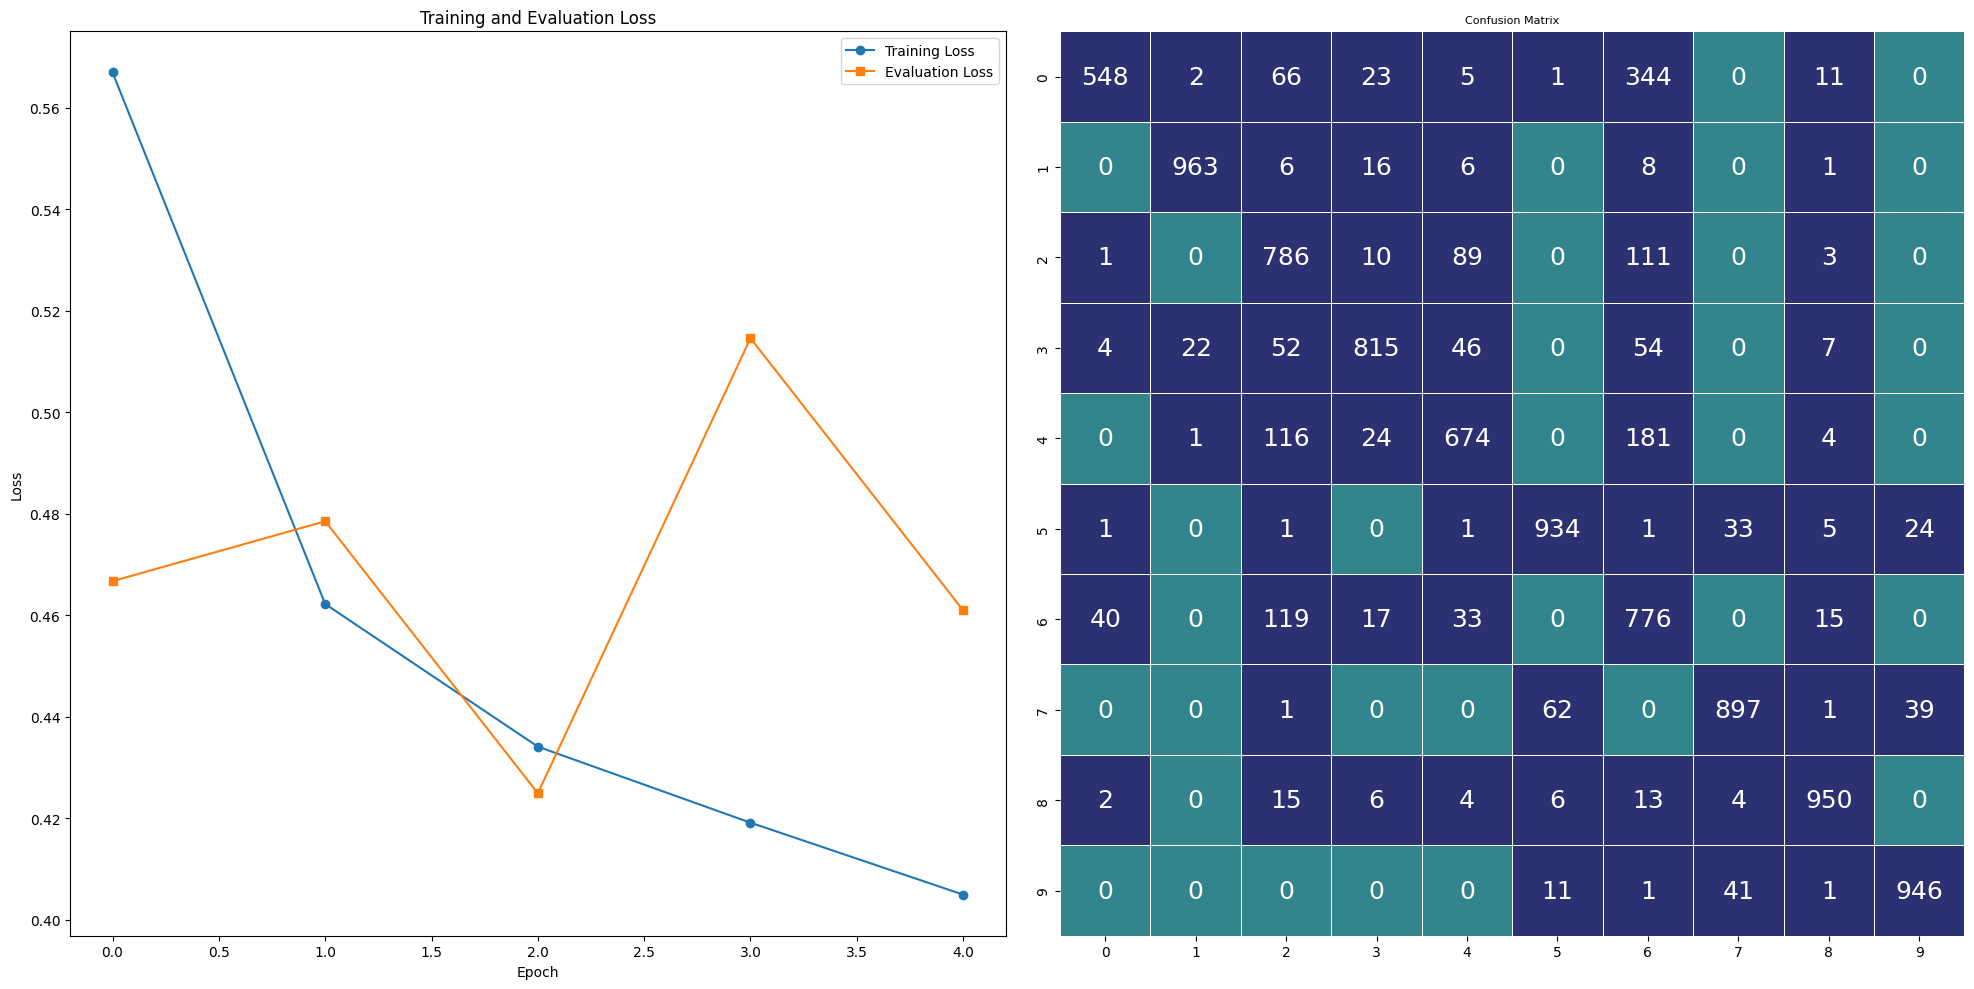

** learning rate: 0.001:


Epoch 1/5 - Training: 100%|██████████| 750/750 [00:39<00:00, 19.19it/s]


 ** Training Loss: 0.5164


Epoch 1/5 - Evaluation: 100%|██████████| 188/188 [00:08<00:00, 22.30it/s]


 ** Evaluation Accuracy: 85.01%




...

 ** Training Loss: 0.3019


Epoch 5/5 - Evaluation: 100%|██████████| 188/188 [00:08<00:00, 21.46it/s]


 ** Evaluation Accuracy: 87.15%


Train time on cuda: 3.970 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:07<00:00, 22.17it/s]


Final Test Accuracy: 86.47%
Wide Neural Network (learning rate: 0.001)


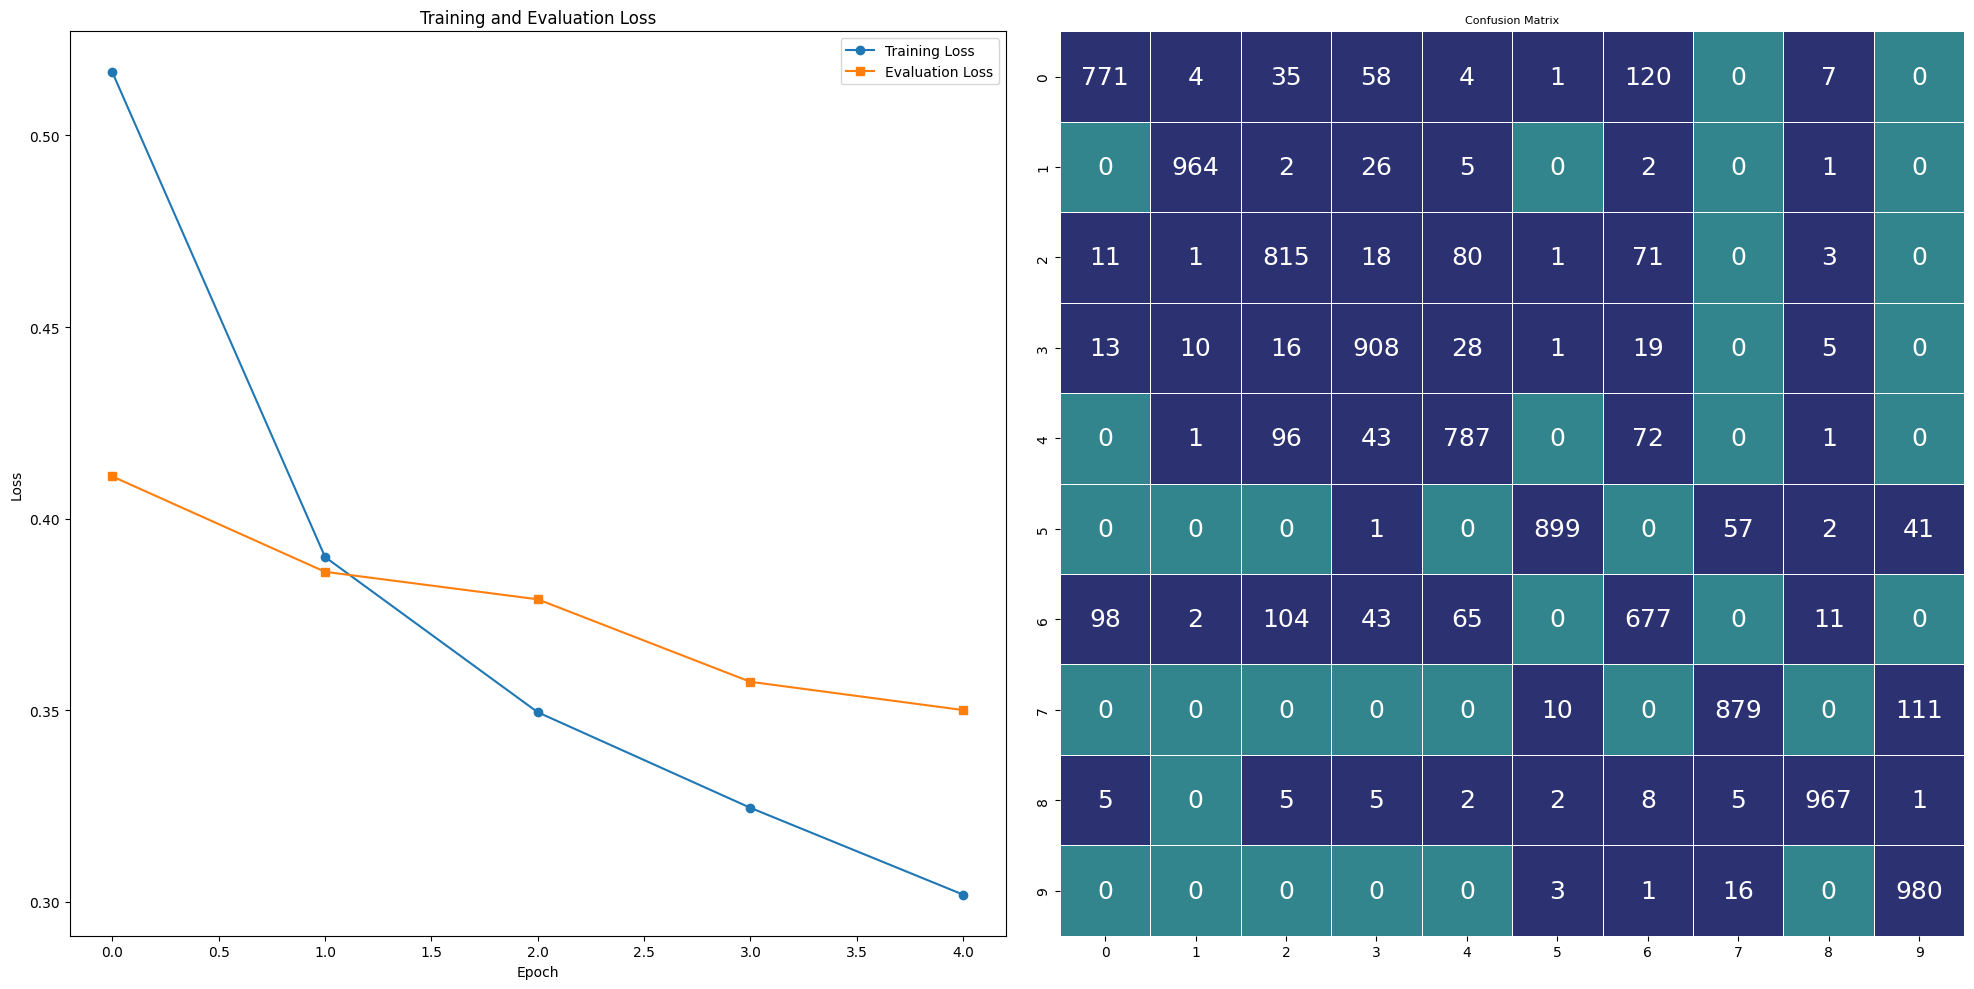

In [223]:
print("training the 'Deep Neural Network': ")deep_rate_accuracy = learning_rate_init(deep=True)print("training the 'Wide Neural Network': ")wide_rate_accuracy = learning_rate_init(deep=False)

In [224]:
compare_table = pd.DataFrame({    "Learning Rate": deep_rate_accuracy.keys(),    "DeepNN Accuracy": deep_rate_accuracy.values(),    "WideNN Accuracy": wide_rate_accuracy.values()})compare_table

,Learning Rate,DeepNN Accuracy,WideNN Accuracy
0,1.000,10.00,10.03
1,0.100,10.00,10.03
2,0.010,84.38,82.89
3,0.001,86.00,86.47


## Q3.2 Batch sizes

In [225]:
def learning_rate_init(deep:bool):    accuracy_dict = {}    batch_sizes = [32, 64, 128, 256]    loss = nn.CrossEntropyLoss()    for batch_size in batch_sizes:        if deep:            model = DeepNN().to(device)        else:            model = WideNN().to(device)        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)        trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)        valloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)        testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)        print(f"** Batch size: {batch_size}:")        train_losses, eval_losses = train_and_evaluate(model, trainloader, valloader, loss, optimizer, device, epochs=5)        conf_matrix, accuracy = testset_prediction(model, testloader, device)        print(f'Deep Neural Network (learning rate: {batch_size})' if deep else f'Wide Neural Network (learning rate: {batch_size})')        plot_train_eval(train_losses, eval_losses, conf_matrix)        accuracy_dict[batch_size] = accuracy    return accuracy_dict

training the 'Deep Neural Network': 
** Batch size: 32:


Epoch 1/5 - Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1/5 - Training: 100%|██████████| 1875/1875 [01:01<00:00, 30.70it/s]


 ** Training Loss: 0.5341


Epoch 1/5 - Evaluation: 100%|██████████| 313/313 [00:08<00:00, 35.95it/s]


...

 ** Training Loss: 0.3100


Epoch 5/5 - Evaluation: 100%|██████████| 313/313 [00:08<00:00, 36.06it/s]


 ** Evaluation Accuracy: 86.21%


Train time on cuda: 5.880 minutes




Final Test Evaluation: 100%|██████████| 313/313 [00:08<00:00, 38.35it/s]


Final Test Accuracy: 86.21%
Deep Neural Network (learning rate: 32)


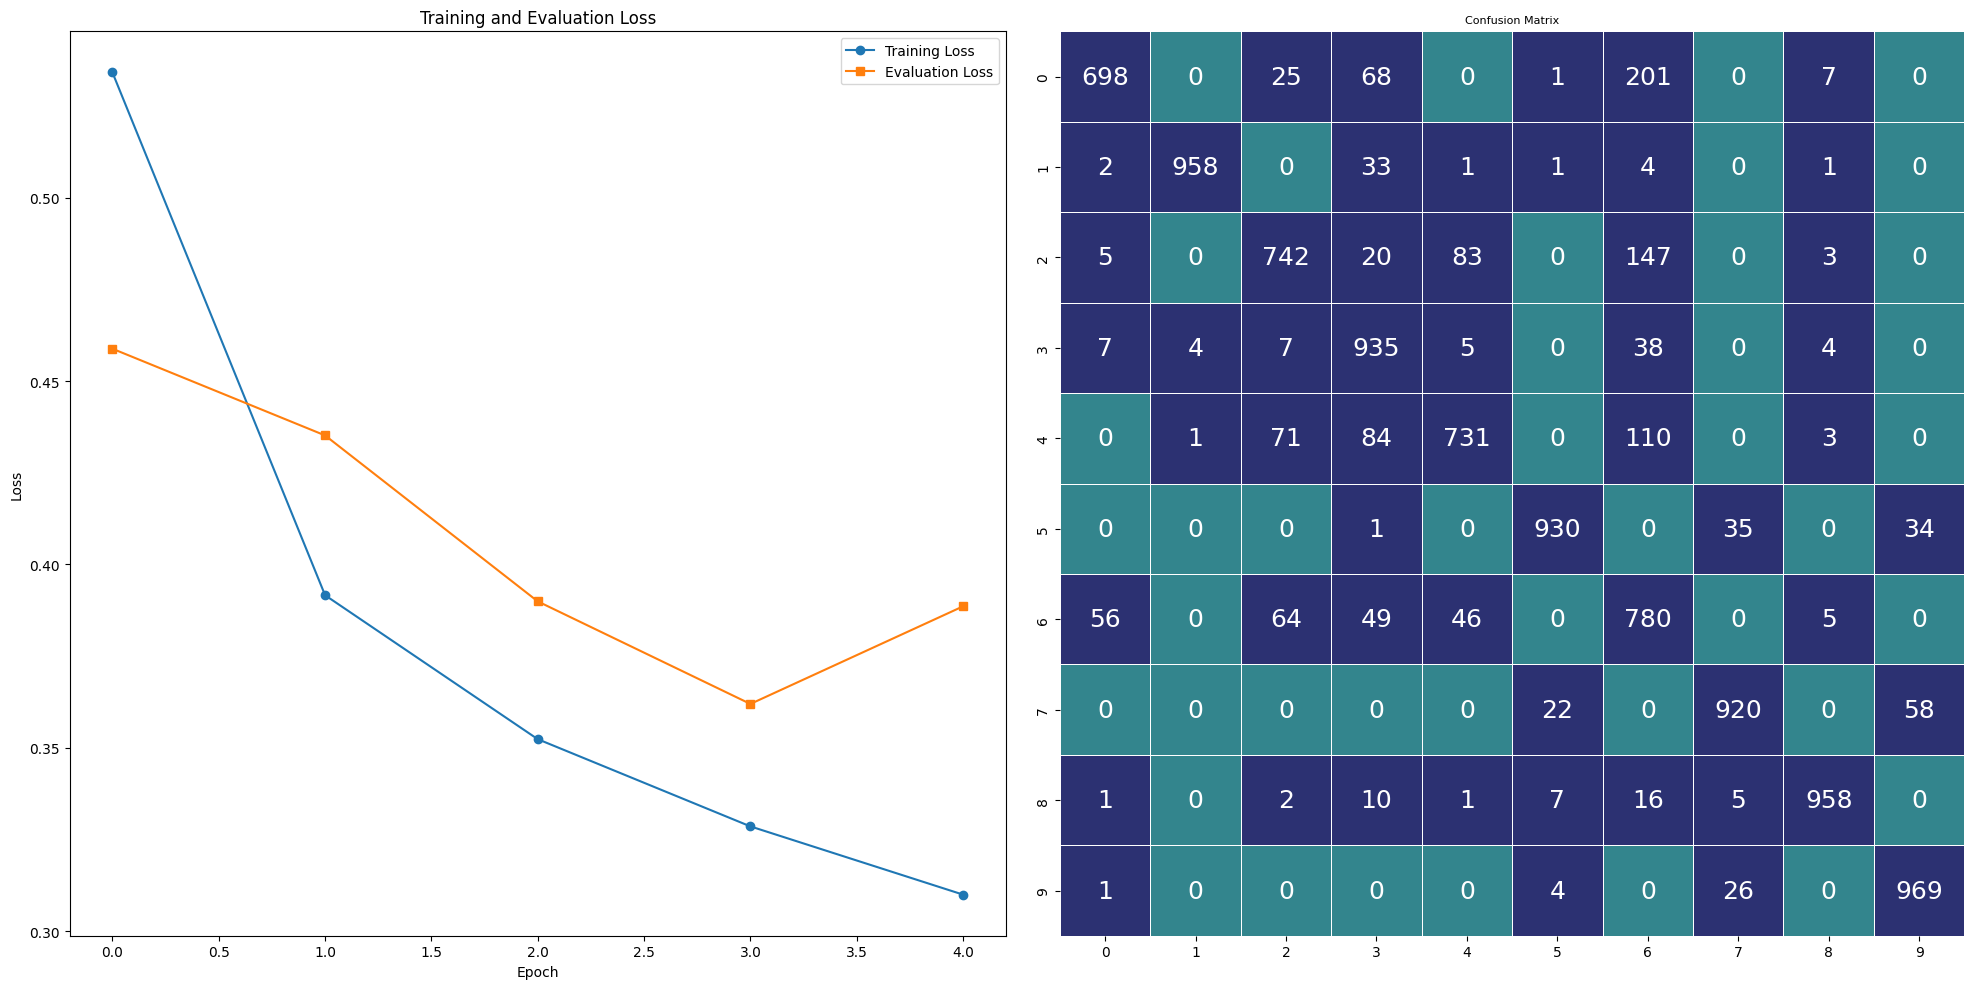

** Batch size: 64:


Epoch 1/5 - Training: 100%|██████████| 938/938 [00:50<00:00, 18.44it/s]


 ** Training Loss: 0.5526


Epoch 1/5 - Evaluation: 100%|██████████| 157/157 [00:07<00:00, 22.08it/s]


 ** Evaluation Accuracy: 83.44%




...

 ** Training Loss: 0.3061


Epoch 5/5 - Evaluation: 100%|██████████| 157/157 [00:07<00:00, 21.79it/s]


 ** Evaluation Accuracy: 86.85%


Train time on cuda: 4.889 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:07<00:00, 21.63it/s]


Final Test Accuracy: 86.85%
Deep Neural Network (learning rate: 64)


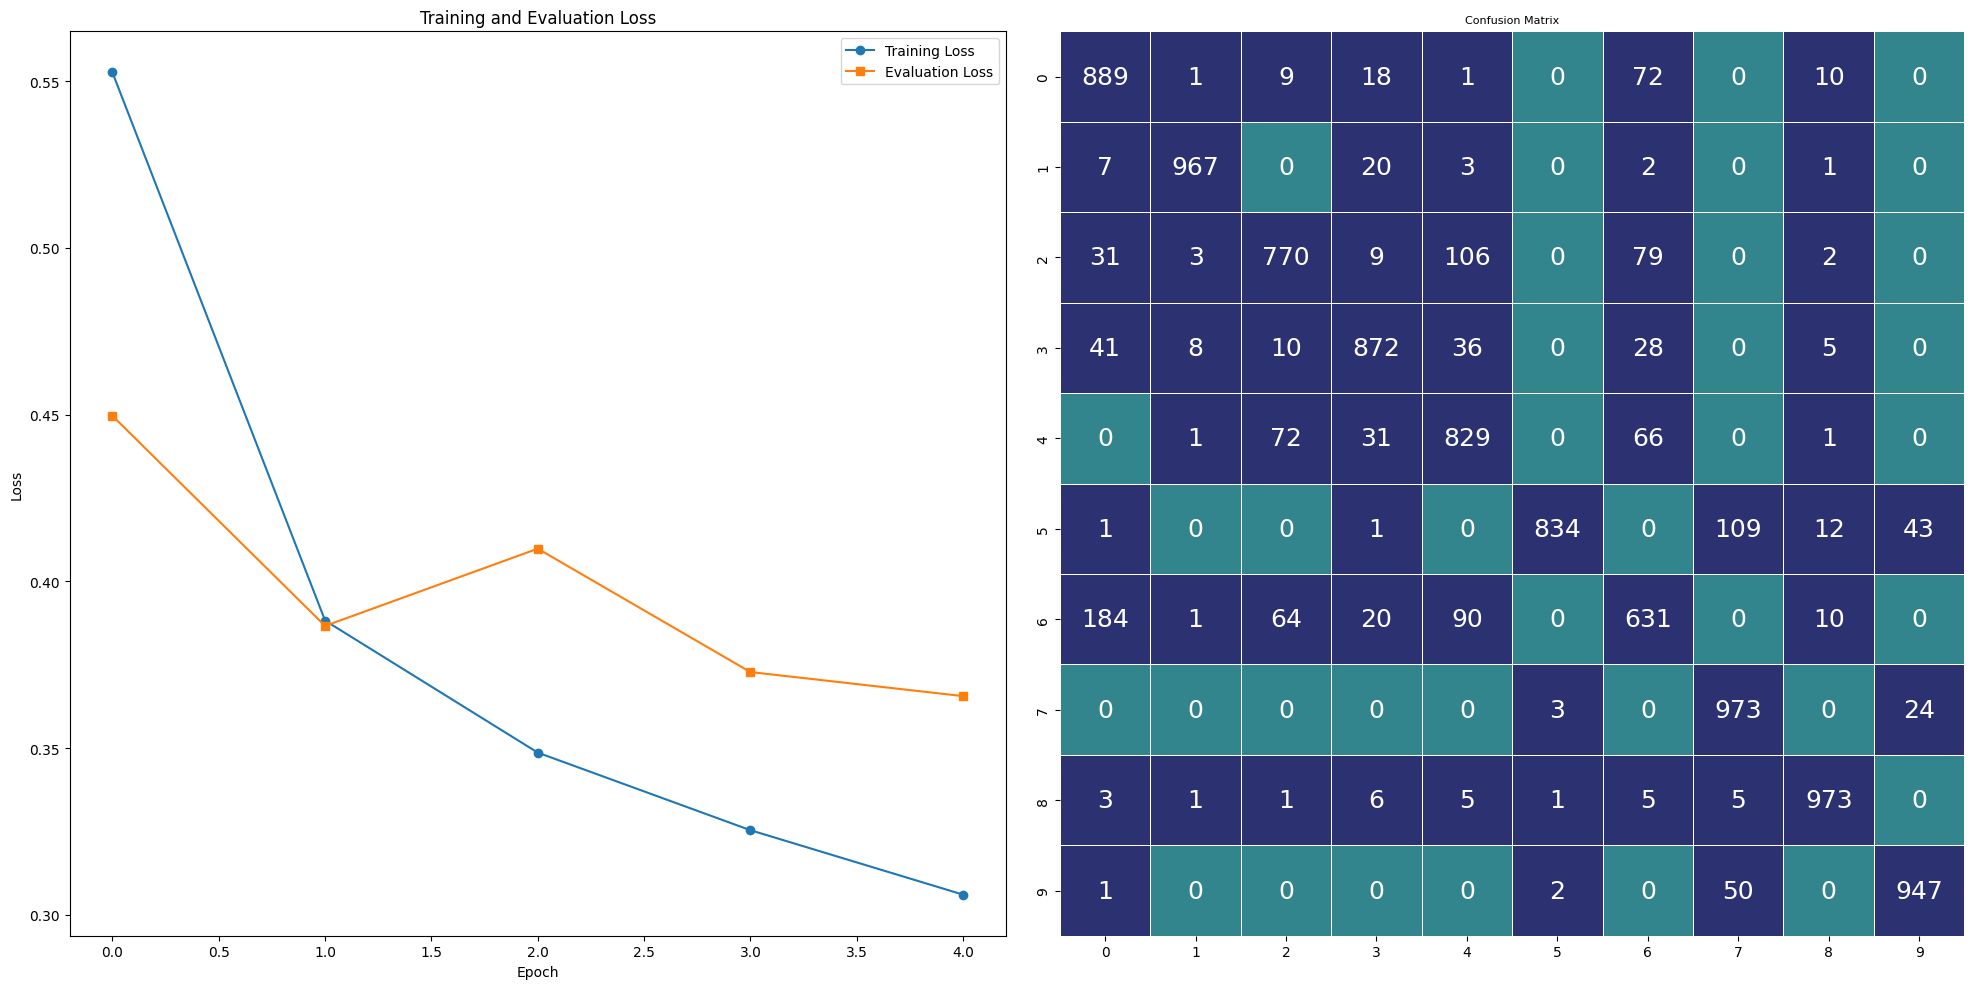

** Batch size: 128:


Epoch 1/5 - Training: 100%|██████████| 469/469 [00:44<00:00, 10.43it/s]


 ** Training Loss: 0.6072


Epoch 1/5 - Evaluation: 100%|██████████| 79/79 [00:06<00:00, 11.75it/s]


 ** Evaluation Accuracy: 83.43%




...

 ** Training Loss: 0.3210


Epoch 5/5 - Evaluation: 100%|██████████| 79/79 [00:06<00:00, 11.73it/s]


 ** Evaluation Accuracy: 86.21%


Train time on cuda: 4.354 minutes




Final Test Evaluation: 100%|██████████| 79/79 [00:06<00:00, 12.47it/s]


Final Test Accuracy: 86.21%
Deep Neural Network (learning rate: 128)


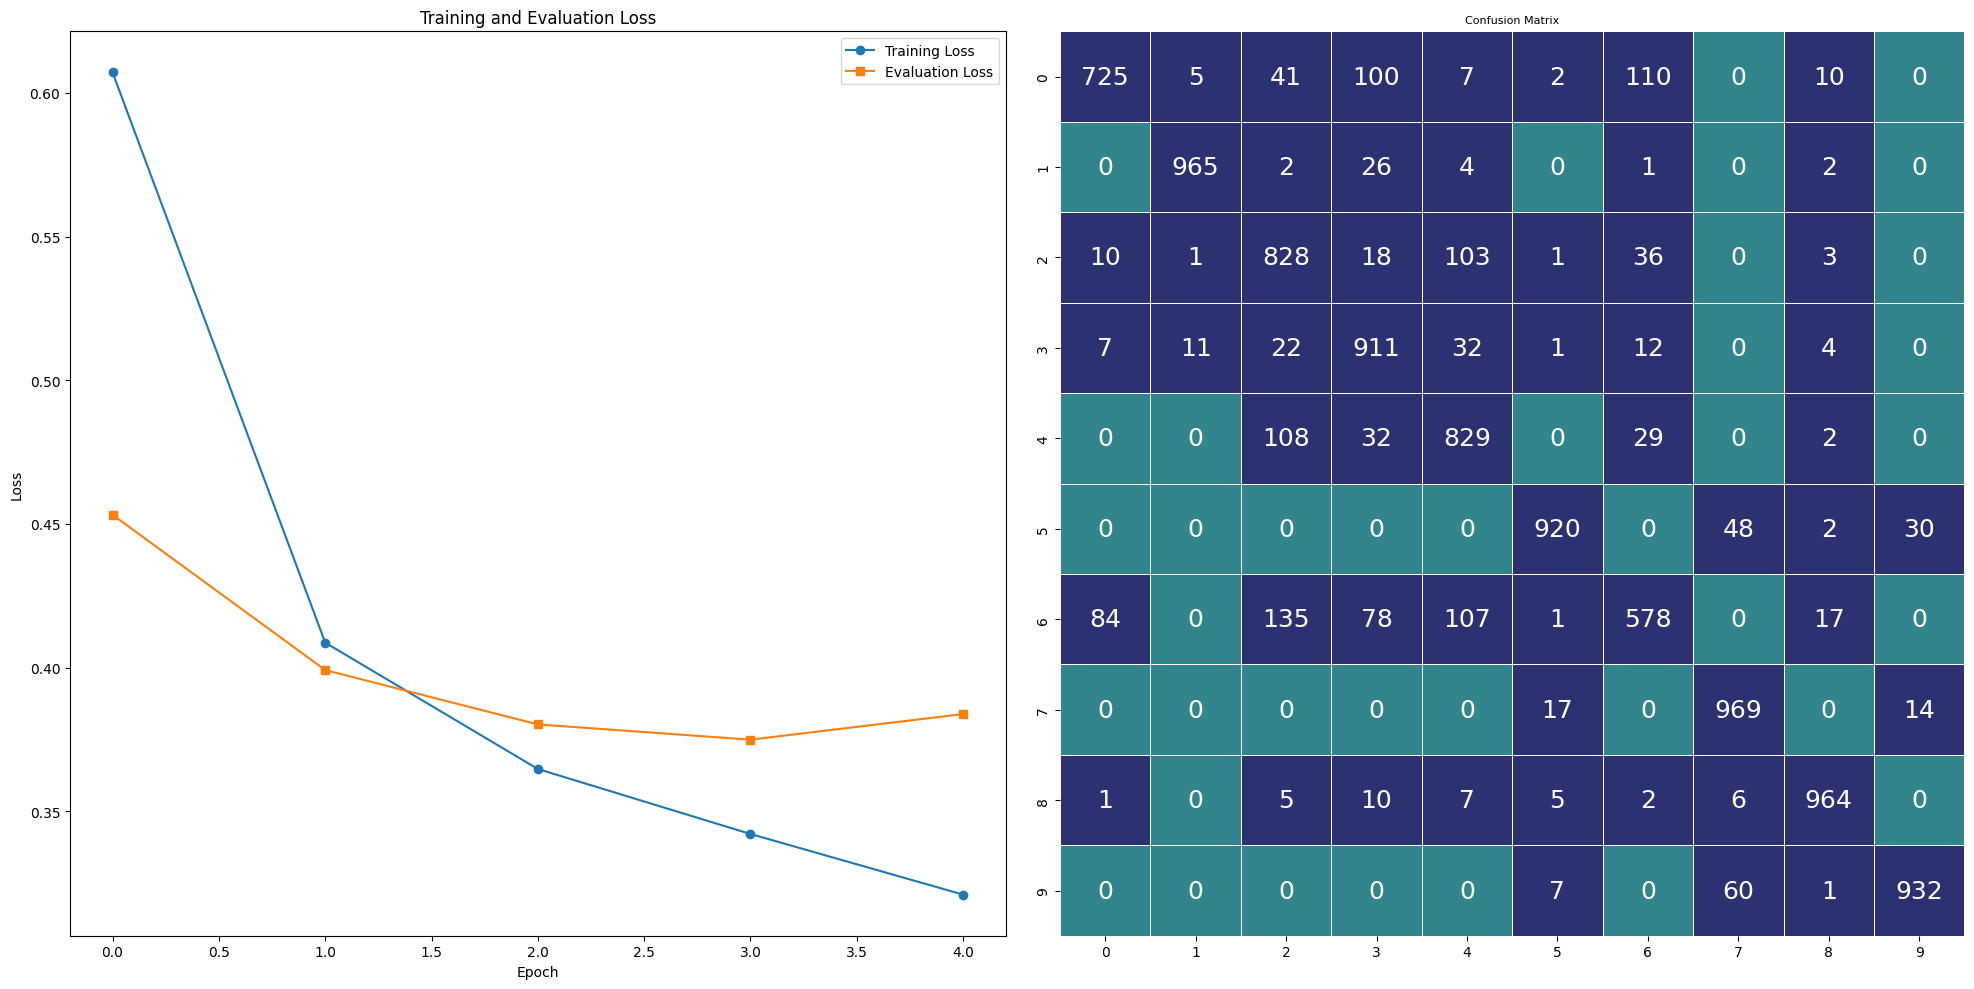

** Batch size: 256:


Epoch 1/5 - Training: 100%|██████████| 235/235 [00:43<00:00,  5.41it/s]


 ** Training Loss: 0.6973


Epoch 1/5 - Evaluation: 100%|██████████| 40/40 [00:06<00:00,  6.48it/s]


 ** Evaluation Accuracy: 81.84%




...

 ** Training Loss: 0.3238


Epoch 5/5 - Evaluation: 100%|██████████| 40/40 [00:07<00:00,  5.65it/s]


 ** Evaluation Accuracy: 85.40%


Train time on cuda: 4.217 minutes




Final Test Evaluation: 100%|██████████| 40/40 [00:06<00:00,  6.27it/s]


Final Test Accuracy: 85.40%
Deep Neural Network (learning rate: 256)


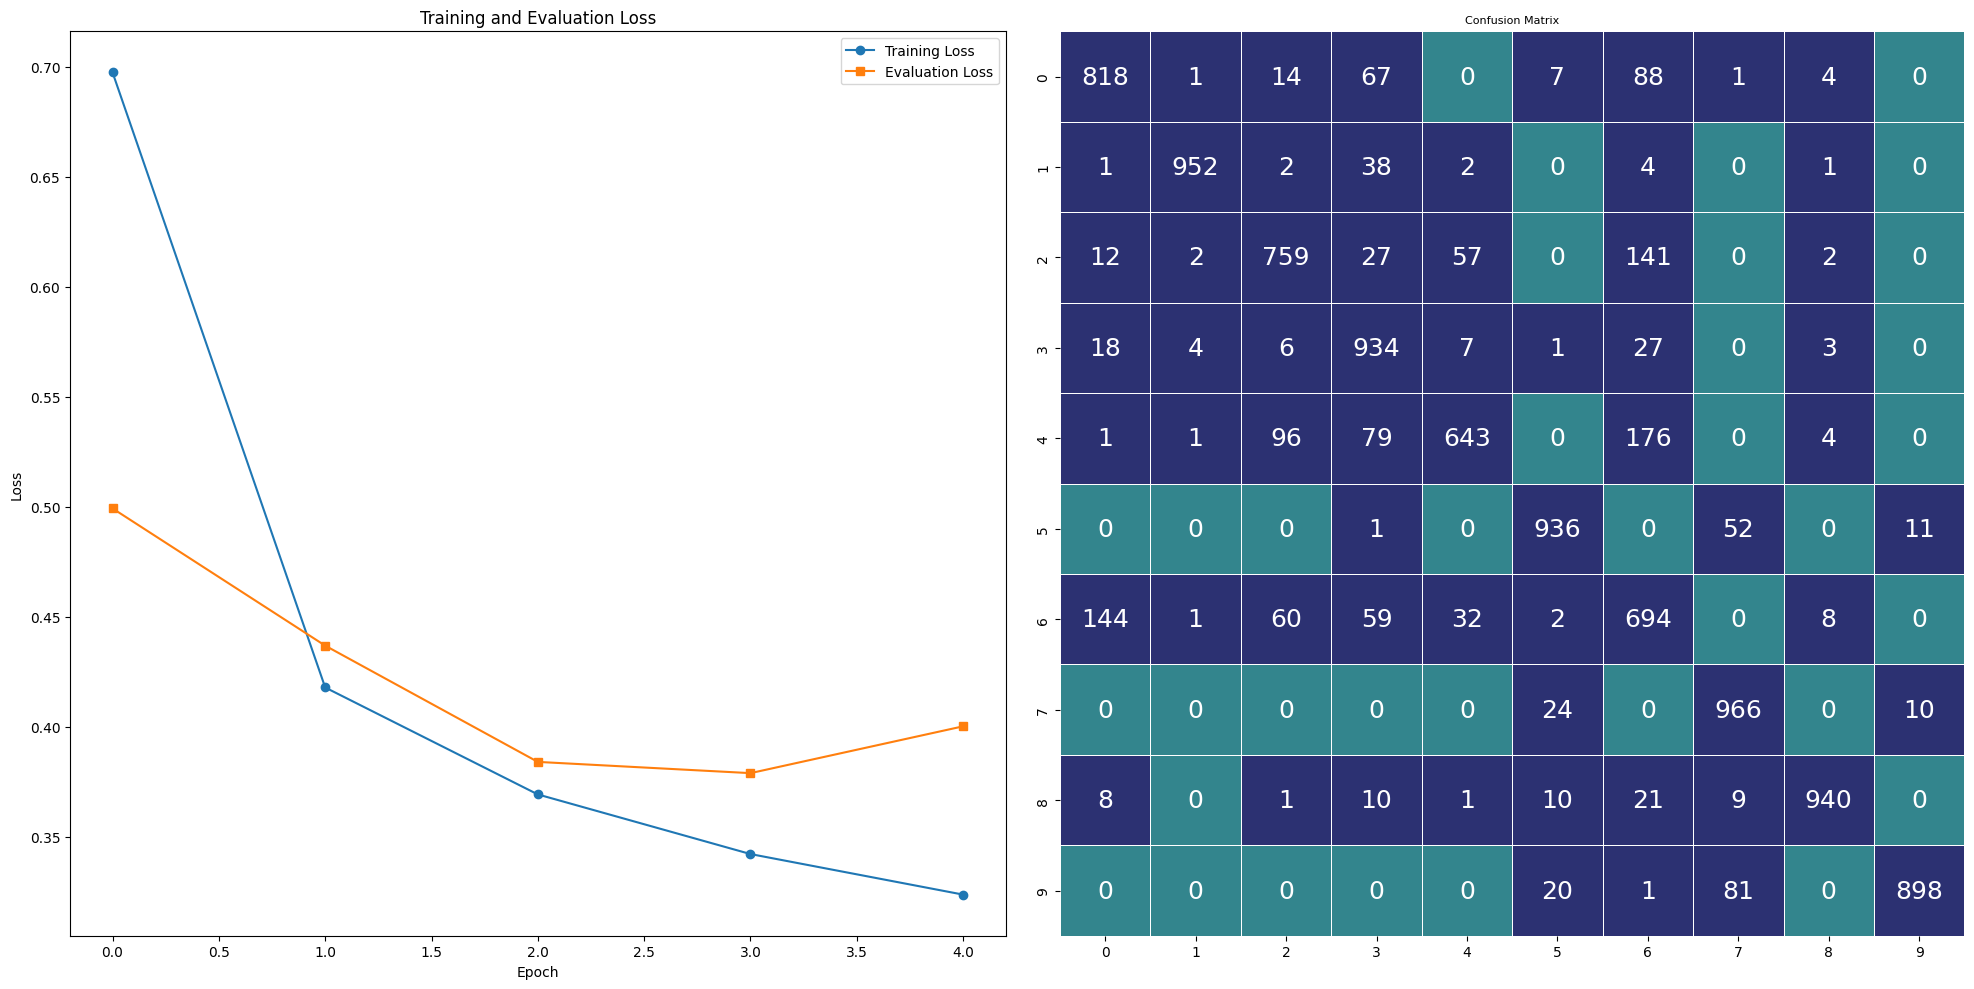

training the 'Wide Neural Network': 
** Batch size: 32:


Epoch 1/5 - Training: 100%|██████████| 1875/1875 [01:00<00:00, 30.95it/s]


 ** Training Loss: 0.4835


Epoch 1/5 - Evaluation: 100%|██████████| 313/313 [00:07<00:00, 40.76it/s]


 ** Evaluation Accuracy: 85.06%




...

 ** Training Loss: 0.3001


Epoch 5/5 - Evaluation: 100%|██████████| 313/313 [00:09<00:00, 33.12it/s]


 ** Evaluation Accuracy: 87.13%


Train time on cuda: 5.788 minutes




Final Test Evaluation: 100%|██████████| 313/313 [00:09<00:00, 33.90it/s]


Final Test Accuracy: 87.13%
Wide Neural Network (learning rate: 32)


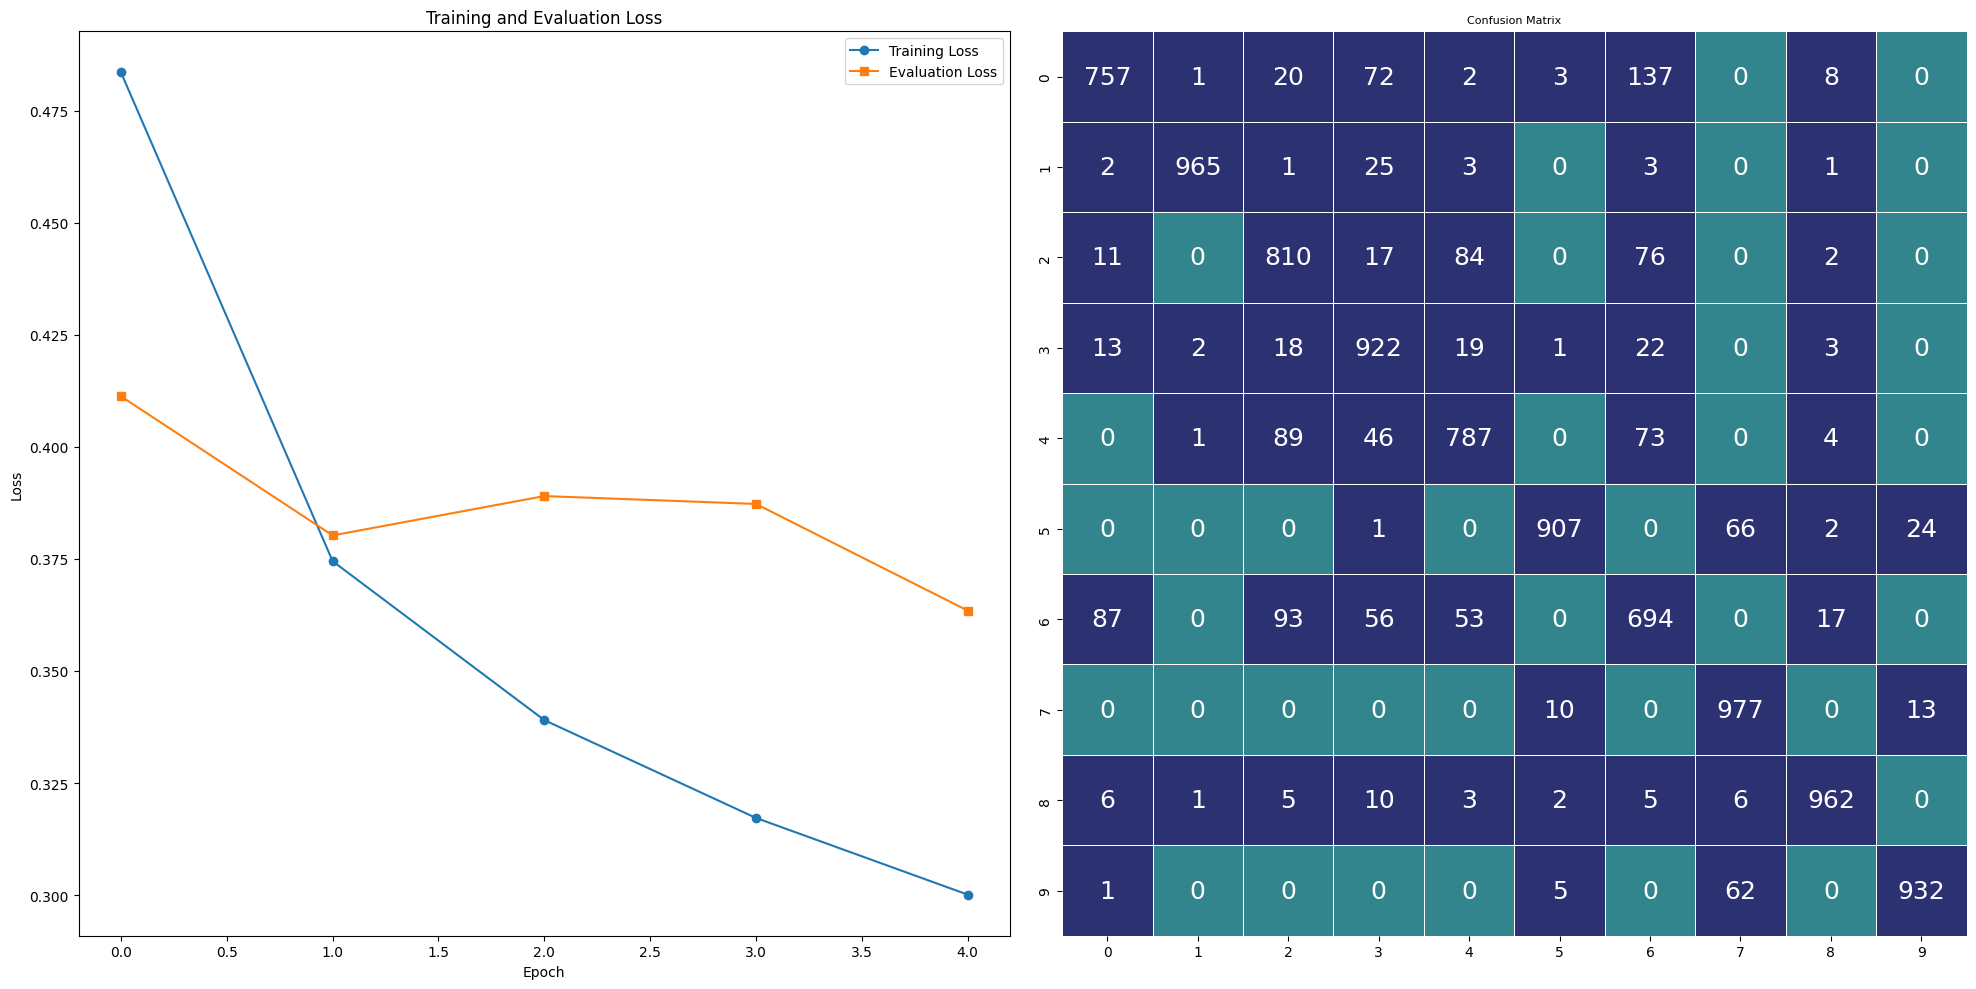

** Batch size: 64:


Epoch 1/5 - Training: 100%|██████████| 938/938 [00:51<00:00, 18.11it/s]


 ** Training Loss: 0.4951


Epoch 1/5 - Evaluation: 100%|██████████| 157/157 [00:06<00:00, 22.84it/s]


 ** Evaluation Accuracy: 84.96%




...

 ** Training Loss: 0.2981


Epoch 5/5 - Evaluation: 100%|██████████| 157/157 [00:06<00:00, 22.79it/s]


 ** Evaluation Accuracy: 87.42%


Train time on cuda: 4.726 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:06<00:00, 22.58it/s]


Final Test Accuracy: 87.42%
Wide Neural Network (learning rate: 64)


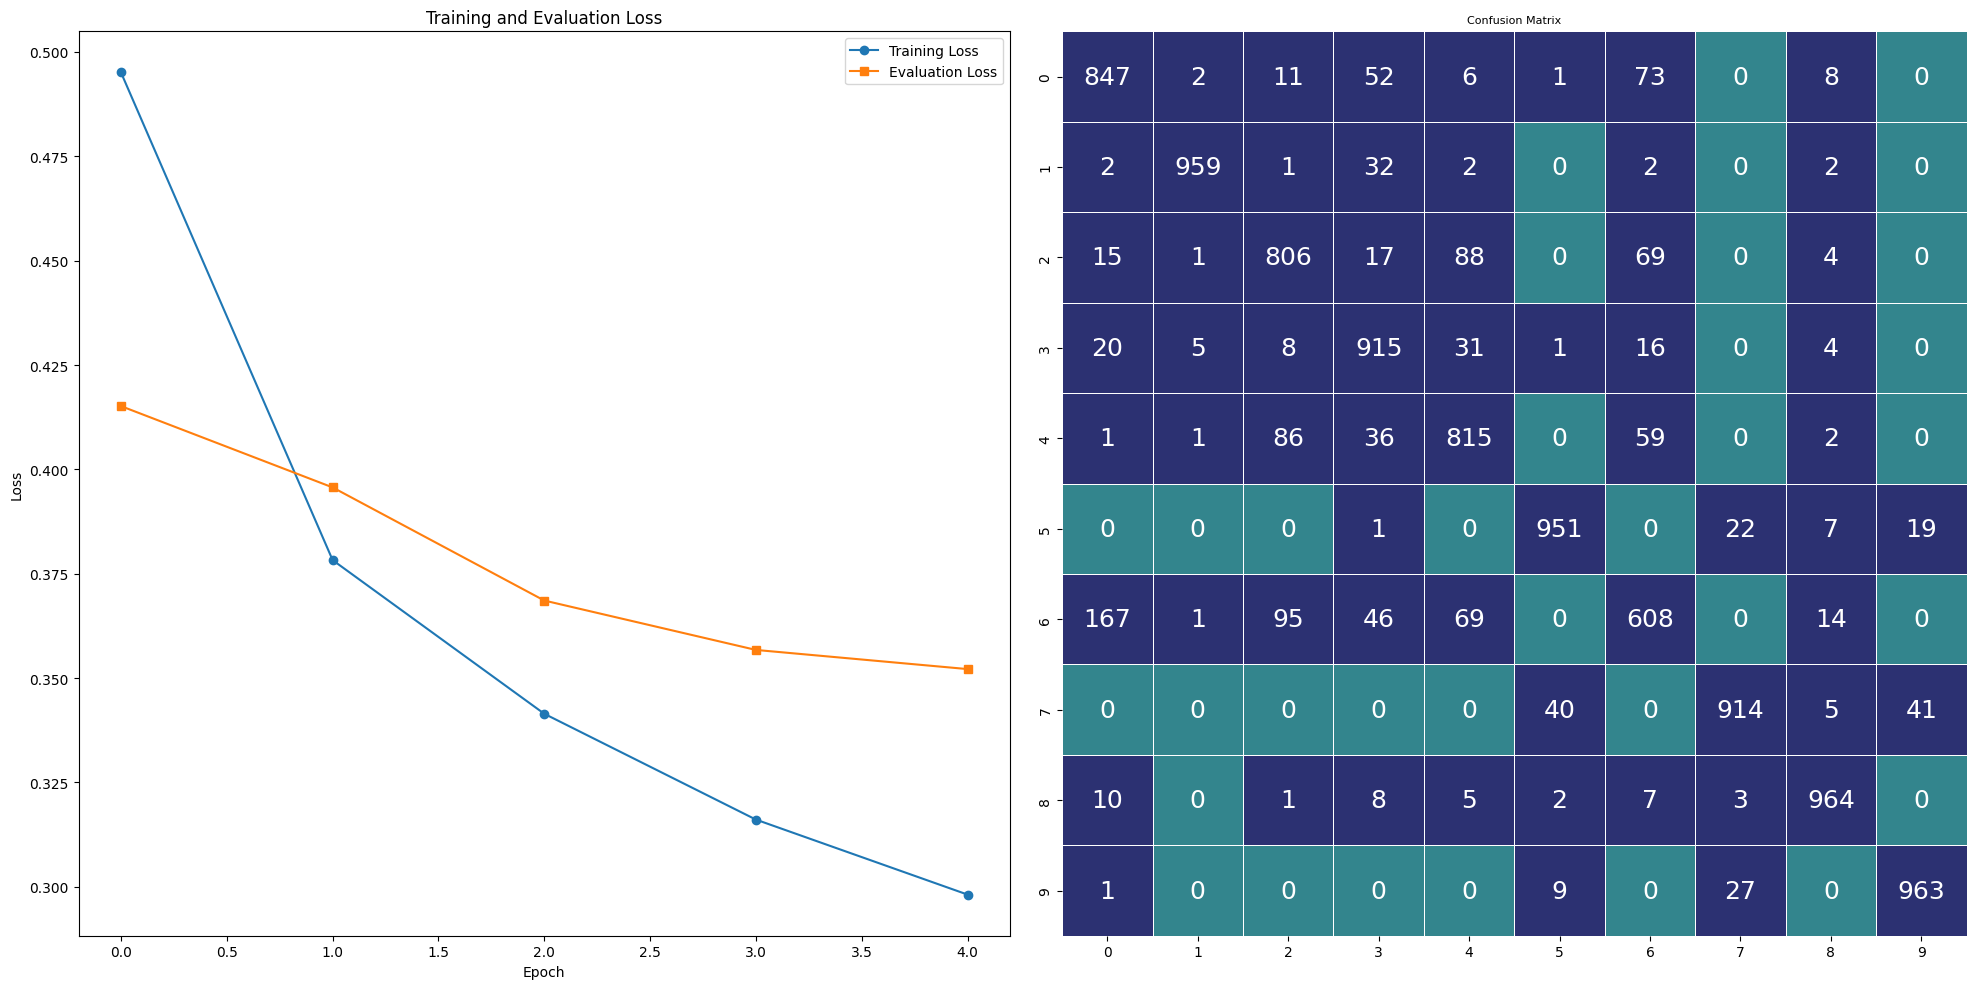

** Batch size: 128:


Epoch 1/5 - Training: 100%|██████████| 469/469 [00:42<00:00, 10.98it/s]


 ** Training Loss: 0.5260


Epoch 1/5 - Evaluation: 100%|██████████| 79/79 [00:06<00:00, 12.55it/s]


 ** Evaluation Accuracy: 83.85%




...

 ** Training Loss: 0.3044


Epoch 5/5 - Evaluation: 100%|██████████| 79/79 [00:06<00:00, 12.44it/s]


 ** Evaluation Accuracy: 85.98%


Train time on cuda: 4.141 minutes




Final Test Evaluation: 100%|██████████| 79/79 [00:06<00:00, 12.61it/s]


Final Test Accuracy: 85.98%
Wide Neural Network (learning rate: 128)


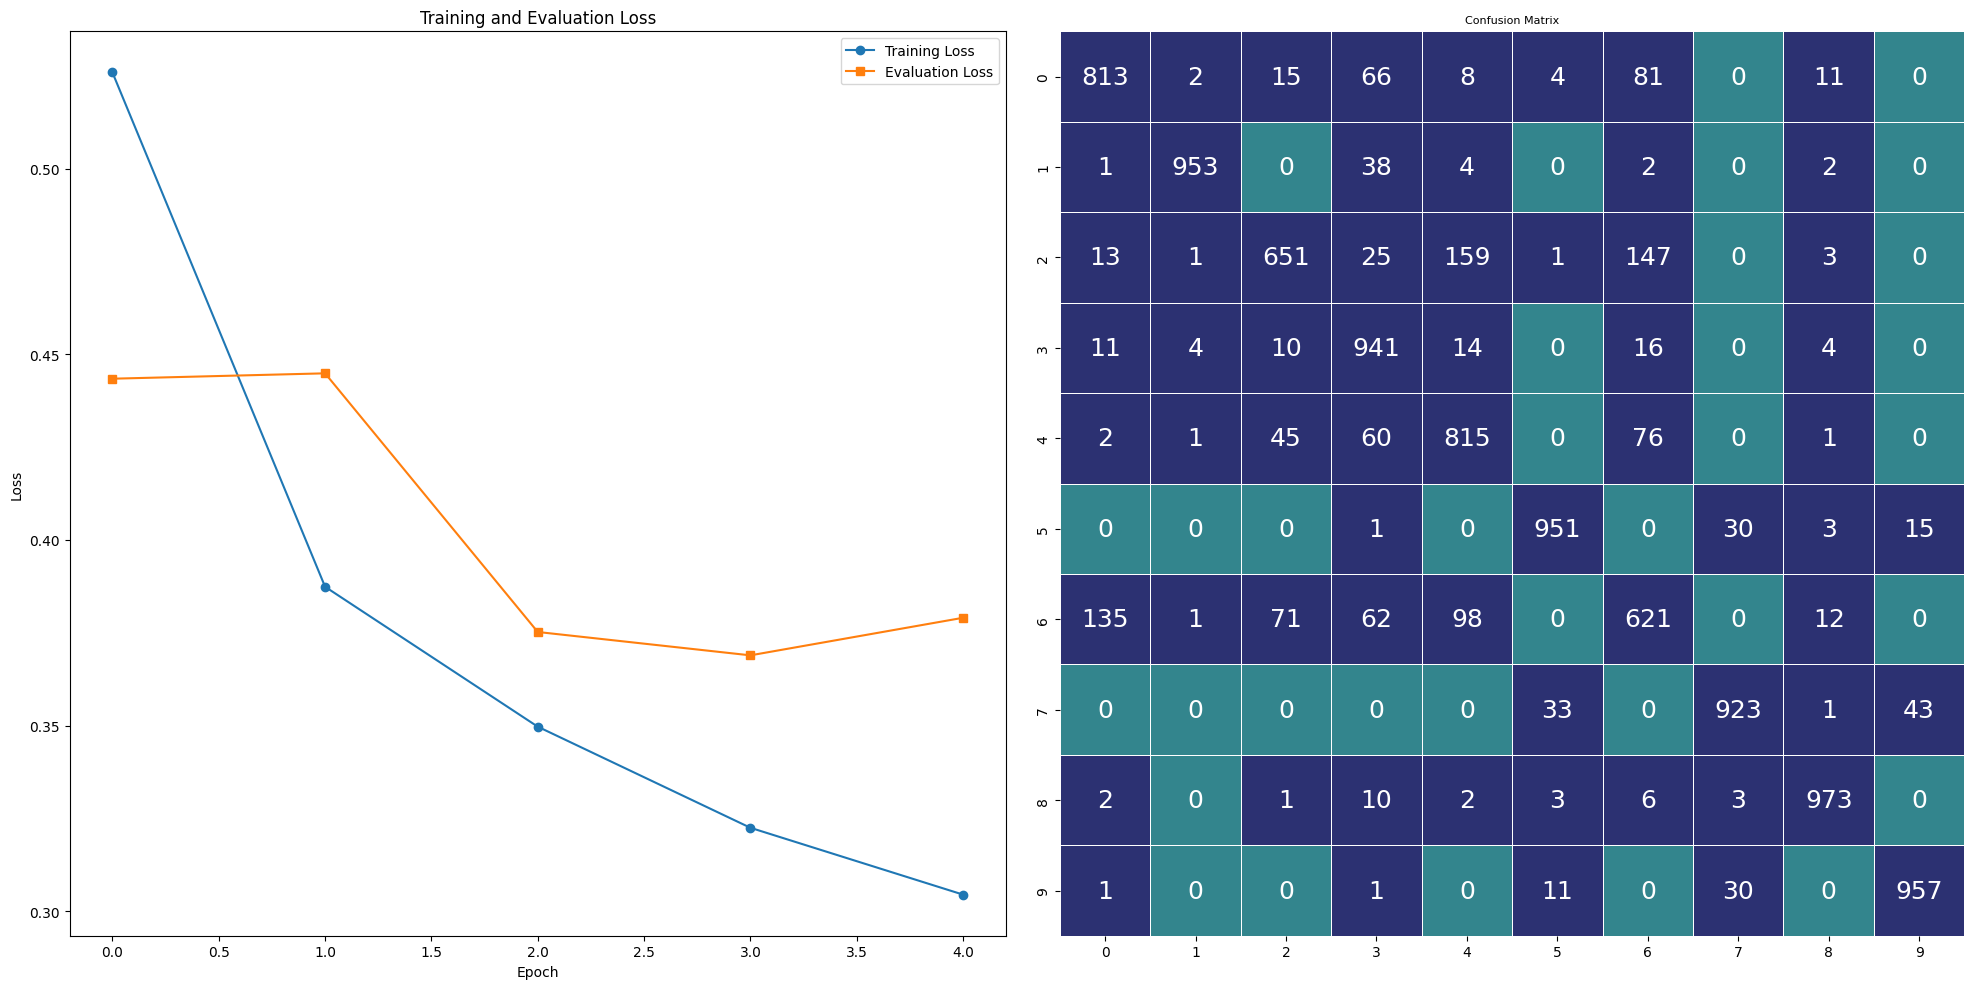

** Batch size: 256:


Epoch 1/5 - Training: 100%|██████████| 235/235 [00:41<00:00,  5.64it/s]


 ** Training Loss: 0.5726


Epoch 1/5 - Evaluation: 100%|██████████| 40/40 [00:06<00:00,  6.22it/s]


 ** Evaluation Accuracy: 82.67%




...

 ** Training Loss: 0.3278


Epoch 5/5 - Evaluation: 100%|██████████| 40/40 [00:07<00:00,  5.55it/s]


 ** Evaluation Accuracy: 86.80%


Train time on cuda: 4.100 minutes




Final Test Evaluation: 100%|██████████| 40/40 [00:06<00:00,  6.23it/s]


Final Test Accuracy: 86.80%
Wide Neural Network (learning rate: 256)


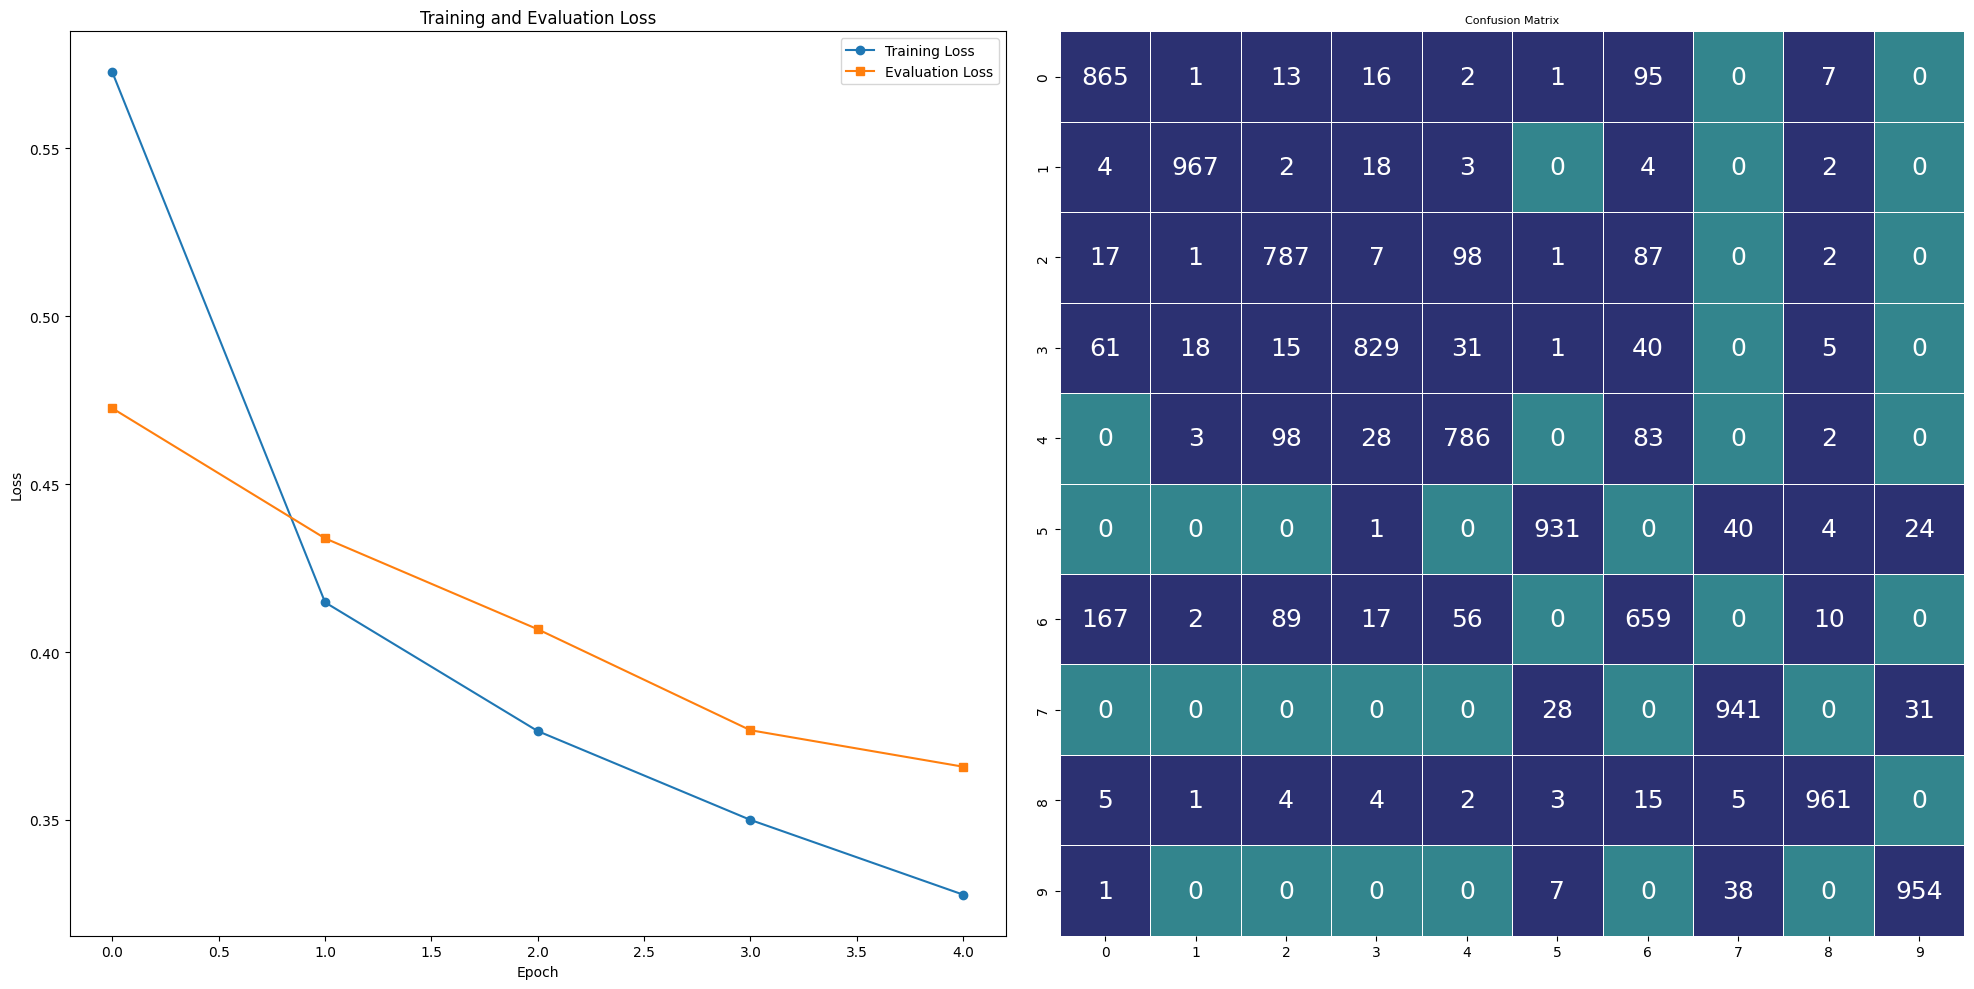

In [226]:
print("training the 'Deep Neural Network': ")deep_batch_accuracy = learning_rate_init(deep=True)print("training the 'Wide Neural Network': ")wide_batch_accuracy = learning_rate_init(deep=False)

In [227]:
compare_table = pd.DataFrame({    "Batch size": deep_batch_accuracy.keys(),    "DeepNN Accuracy": deep_batch_accuracy.values(),    "WideNN Accuracy": wide_batch_accuracy.values()})compare_table

,Batch size,DeepNN Accuracy,WideNN Accuracy
0,32,86.21,87.13
1,64,86.85,87.42
2,128,86.21,85.98
3,256,85.40,86.80


In [228]:
deep_model = DeepNN().to(device)wide_model = WideNN().to(device)deep_loss = nn.CrossEntropyLoss()wide_loss = nn.CrossEntropyLoss()deep_SGD = torch.optim.SGD(deep_model.parameters(), lr=0.001)wide_SGD = torch.optim.Adam(wide_model.parameters(), lr=0.001)

Epoch 1/10 - Training:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 1/10 - Training: 100%|██████████| 750/750 [00:43<00:00, 17.22it/s]


 ** Training Loss: 2.3053


Epoch 1/10 - Evaluation: 100%|██████████| 188/188 [00:11<00:00, 17.08it/s]


 ** Evaluation Accuracy: 10.79%




...

 ** Training Loss: 2.2942


Epoch 10/10 - Evaluation: 100%|██████████| 188/188 [00:13<00:00, 14.00it/s]


 ** Evaluation Accuracy: 9.68%


Train time on cuda: 9.063 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:08<00:00, 19.29it/s]


Final Test Accuracy: 10.30%
Deep Neural Network ('SGD' optimizer)


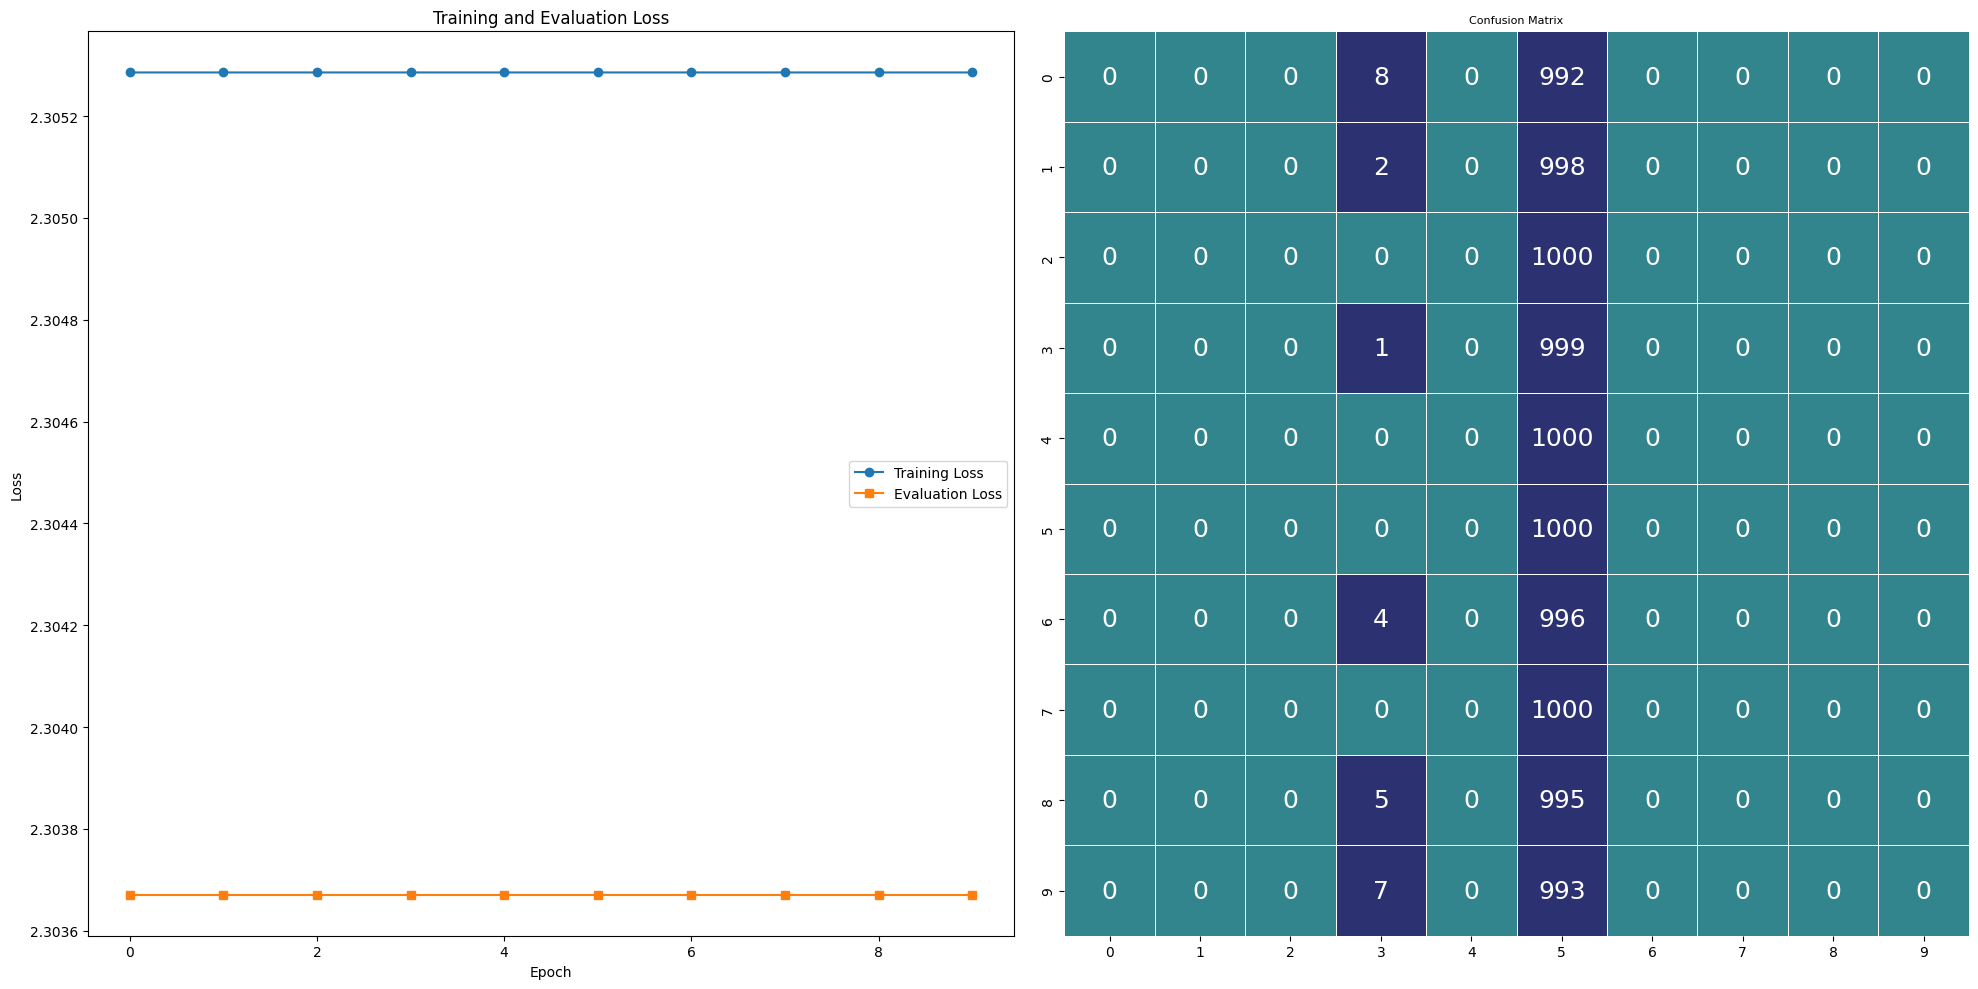

Wide Neural Network ('SGD' optimizer)


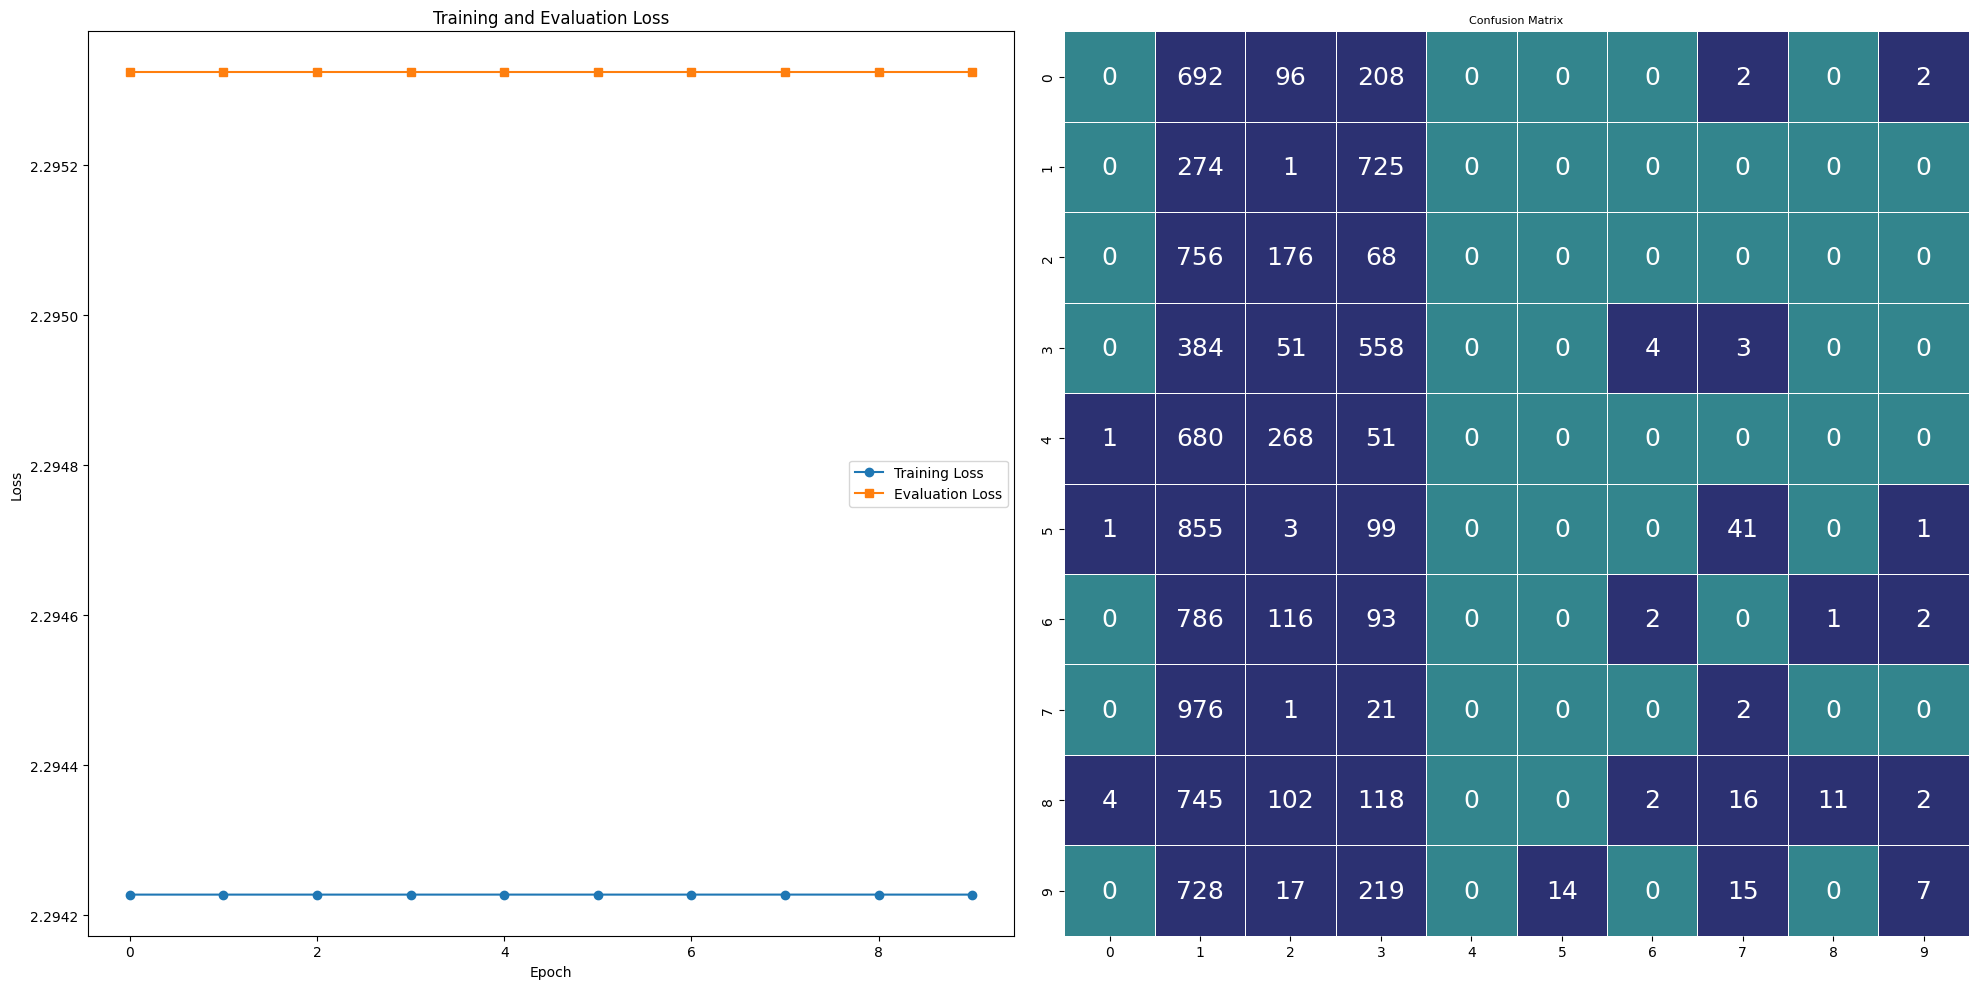

In [ ]:
deep_train_loss, deep_eval_loss = train_and_evaluate(model=deep_model, trainloader=trainloader, valloader=valloader, loss_fn=deep_loss, optimizer=deep_optimizer, device=device, epochs=10)deep_SGD_cm, deep_SGD_acc = testset_prediction(model=deep_model, testloader=testloader, device=device)wide_train_loss, wide_eval_loss = train_and_evaluate(model=wide_model, trainloader=trainloader, valloader=valloader, loss_fn=wide_loss, optimizer=wide_optimizer, device=device, epochs=10)wide_SGD_cm, wide_SGD_acc = testset_prediction(model=wide_model, testloader=testloader, device=device)

Deep Neural Network ('SGD' optimizer)


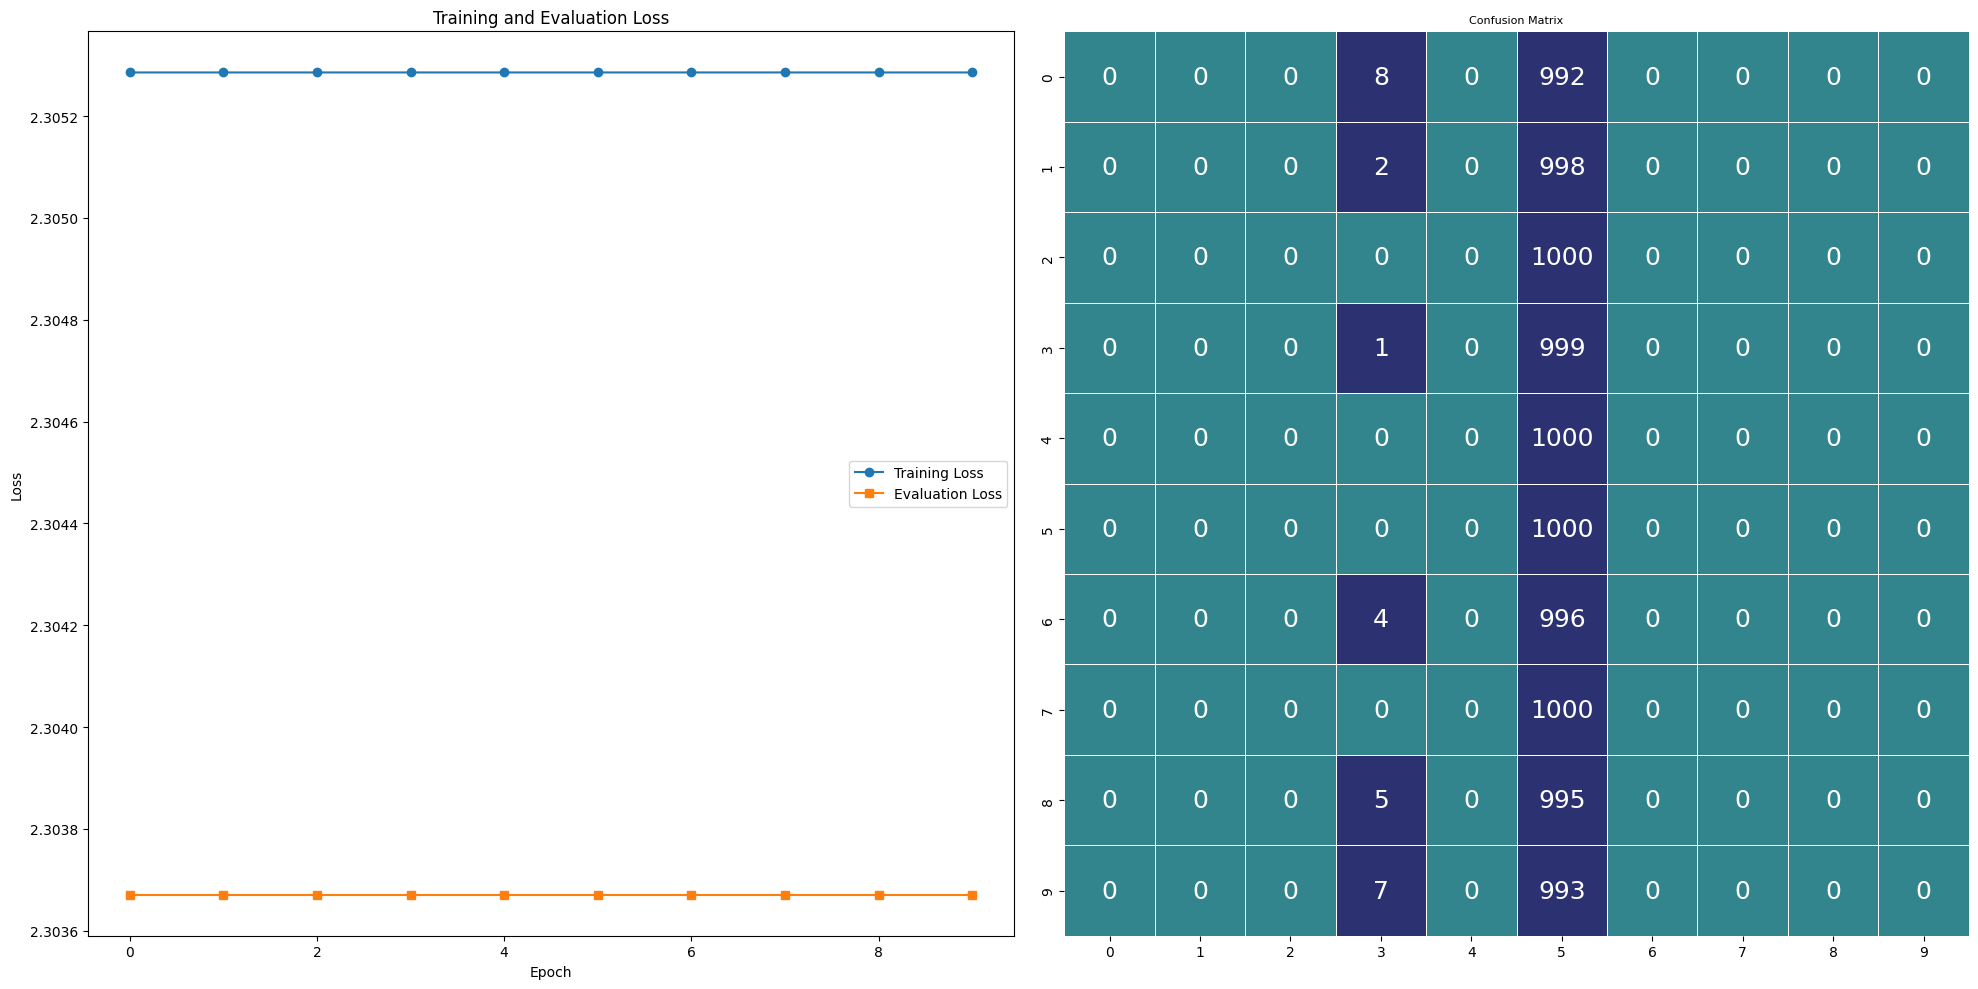

Wide Neural Network ('SGD' optimizer)


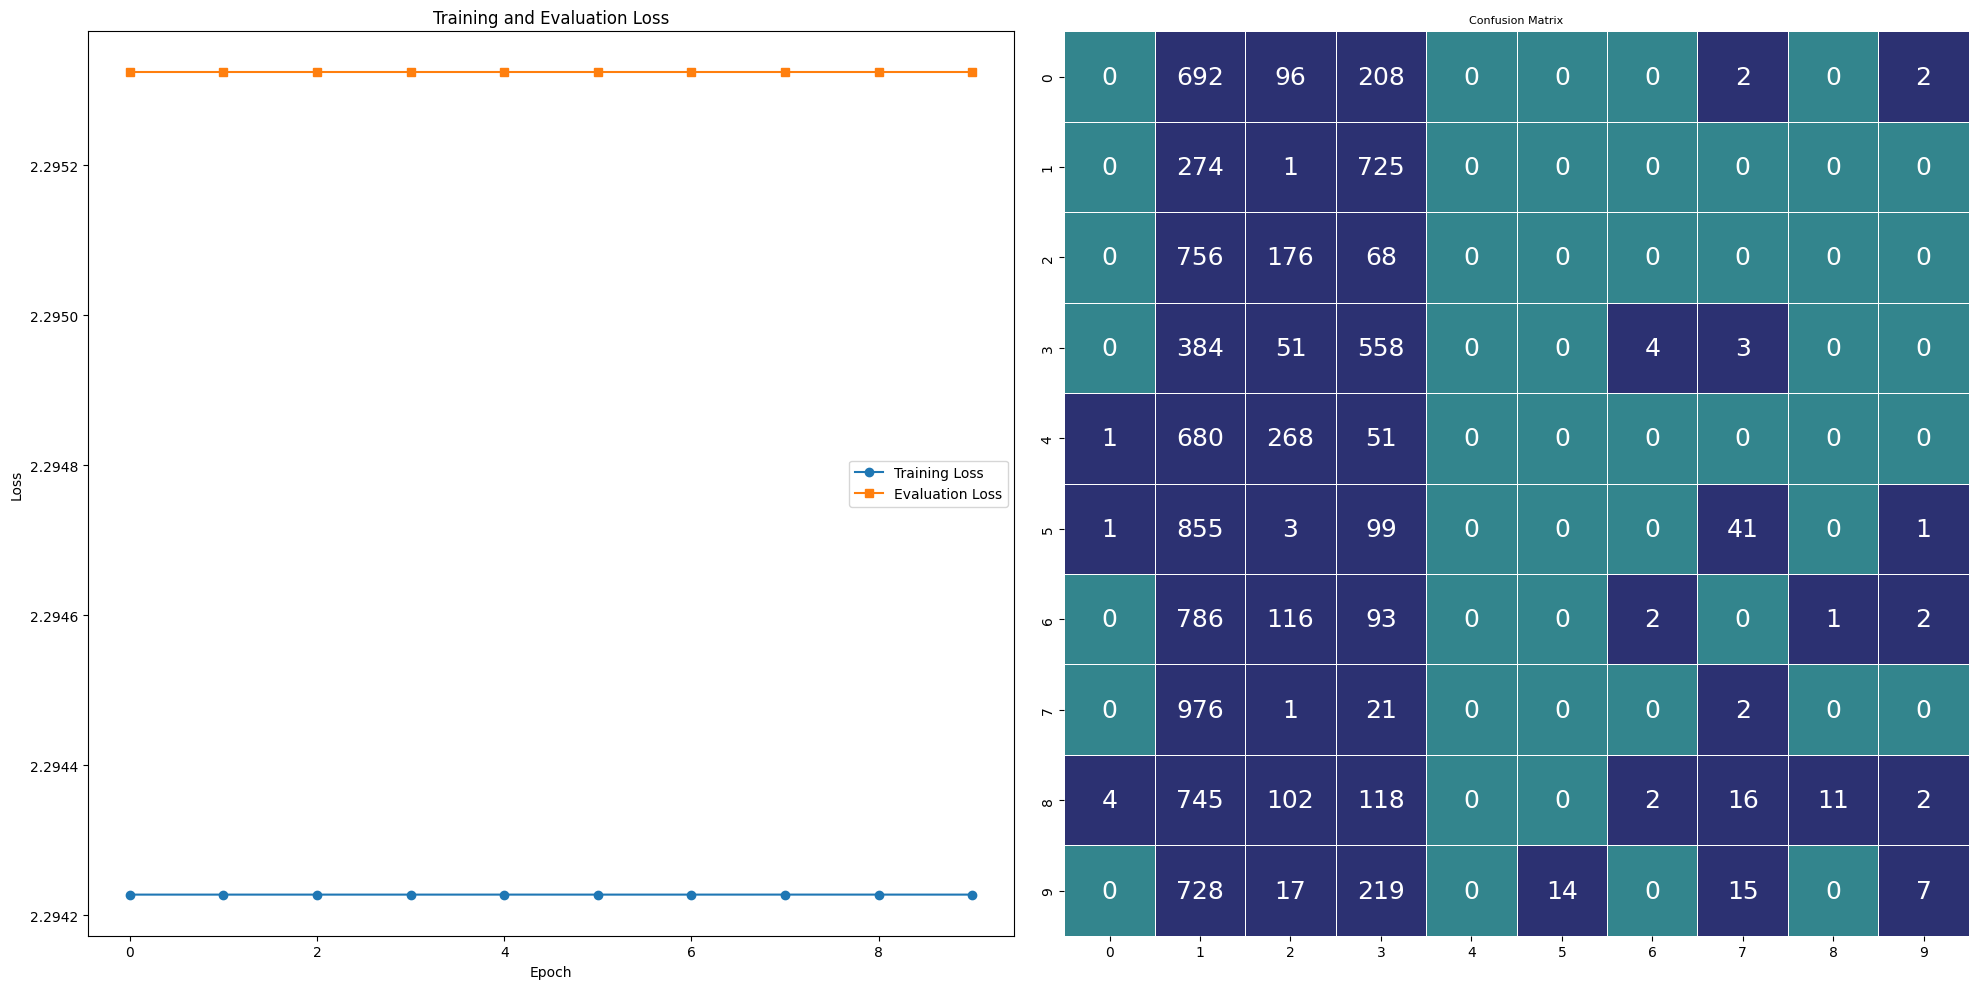

In [231]:
print("Deep Neural Network ('SGD' optimizer)")plot_train_eval(deep_train_loss, deep_eval_loss, deep_SGD_cm)print("Wide Neural Network ('SGD' optimizer)")plot_train_eval(wide_train_loss, wide_eval_loss, wide_SGD_cm)

In [230]:
compare_table = {    "Optimizer": ["SGD", "Adam"],    "DeepNN": [deep_SGD_acc, deep_Adam_acc],    "WideNN": [wide_SGD_acc, wide_Adam_acc]}compare_table = pd.DataFrame(compare_table)compare_table

,Optimizer,DeepNN,WideNN
0,SGD,10.01,10.30
1,Adam,87.43,88.08
